In [1]:
%load_ext autoreload
%autoreload 2

# Multi-Station QC Evaluation

This notebook loads hourly observations for three stations, converts them to daily values, and runs the modular QC flow for each station. The station selection uses the shared SQL query for network 2 and the requested variables.

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import sqlalchemy as sa
from sqlalchemy.orm import Session
# Make the function folder and package root available
sys.path.append(os.path.abspath('./func/'))
sys.path.append(os.path.abspath('../../'))


save_path = './comparison_forms/'
db_url = "postgresql://tongli1997@db.pcic.uvic.ca:5433/crmp?keepalives=1&keepalives_idle=300&keepalives_interval=300&keepalives_count=9&passfile=/workspaces/crmprtd/.pgpass"
engine = sa.create_engine(db_url, echo=False)
session = Session(engine)
session

In [3]:
from func_run_qc_pipeline import *

from visualizaion_func import (
    plot_weather_data,
    plot_timeseries_with_naught_missing_multi,
    plot_multi_range_check,
    plot_clim_check_multi,
    plot_inttemp_tas_timeseries,
    plot_inttemp_snow_tmin_timeseries,
    plot_inttemp_snow_fall_dpth_timeseries,
    plot_inttemp_snow_precip_timeseries,
)

In [4]:
sql_text = sa.text("""
SELECT s.station_id, h.station_name
FROM meta_history h
JOIN meta_station s
    ON h.station_id = s.station_id
WHERE s.network_id = 2

AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'MINIMUM_AIR_TEMPERATURE'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'MAXIMUM_AIR_TEMPERATURE'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'min_air_temp_snc_last_reset'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'max_air_temp_snc_last_reset'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'air_temp'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'pcpn_amt_pst1hr'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'snwfl_amt_pst1hr'
)
AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.net_var_name = 'snw_dpth'
)
;

""")

with engine.begin() as conn:
    df = pd.read_sql(sql_text, conn)

df

,station_id,station_name
0,2668,Nicolum Creek
1,2794,Nordic 2
2,2955,North Courtenay
3,2902,Onion Lake
4,2764,Paulson Summit
...,...,...
97,2834,West Twin Creek
98,2870,Enterprise
99,2891,Endgoal
100,2906,Salvus


In [45]:
# replace with the three station IDs you want to evaluate
stations_to_eval = df['station_id'].head(10)
# stations_to_eval = [2955]

sql_text = sa.text(
    """
SELECT s.station_id, o.obs_time, v.net_var_name, o.datum
FROM meta_history h
JOIN meta_station s ON h.station_id = s.station_id
JOIN obs_raw o ON o.history_id = h.history_id
JOIN meta_vars v ON o.vars_id = v.vars_id
WHERE s.network_id = 2
AND s.station_id IN :stations
AND v.net_var_name IN (
    'MINIMUM_AIR_TEMPERATURE',
    'MAXIMUM_AIR_TEMPERATURE',
    'min_air_temp_snc_last_reset',
    'max_air_temp_snc_last_reset',
    'air_temp',
    'pcpn_amt_pst1hr',
    'snwfl_amt_pst1hr',
    'snw_dpth'
)
ORDER BY s.station_id, o.obs_time
""")

with engine.begin() as conn:
    df_obs = pd.read_sql(sql_text, conn, params={
                         "stations": tuple(stations_to_eval)})

print("Loaded observations for", df_obs["station_id"].nunique(), "stations")
print(df_obs.head())

Loaded observations for 10 stations
   station_id            obs_time             net_var_name  datum
0        2668 2002-08-23 11:00:00  MINIMUM_AIR_TEMPERATURE   22.6
1        2668 2002-08-23 11:00:00  MAXIMUM_AIR_TEMPERATURE   24.8
2        2668 2002-08-23 12:00:00  MINIMUM_AIR_TEMPERATURE   22.6
3        2668 2002-08-23 12:00:00  MAXIMUM_AIR_TEMPERATURE   27.3
4        2668 2002-08-23 13:00:00  MINIMUM_AIR_TEMPERATURE   22.6


## Build daily data and run QC for each station

The following cells convert hourly data to daily, then execute the modular QC pipeline for each station.

Station 2668


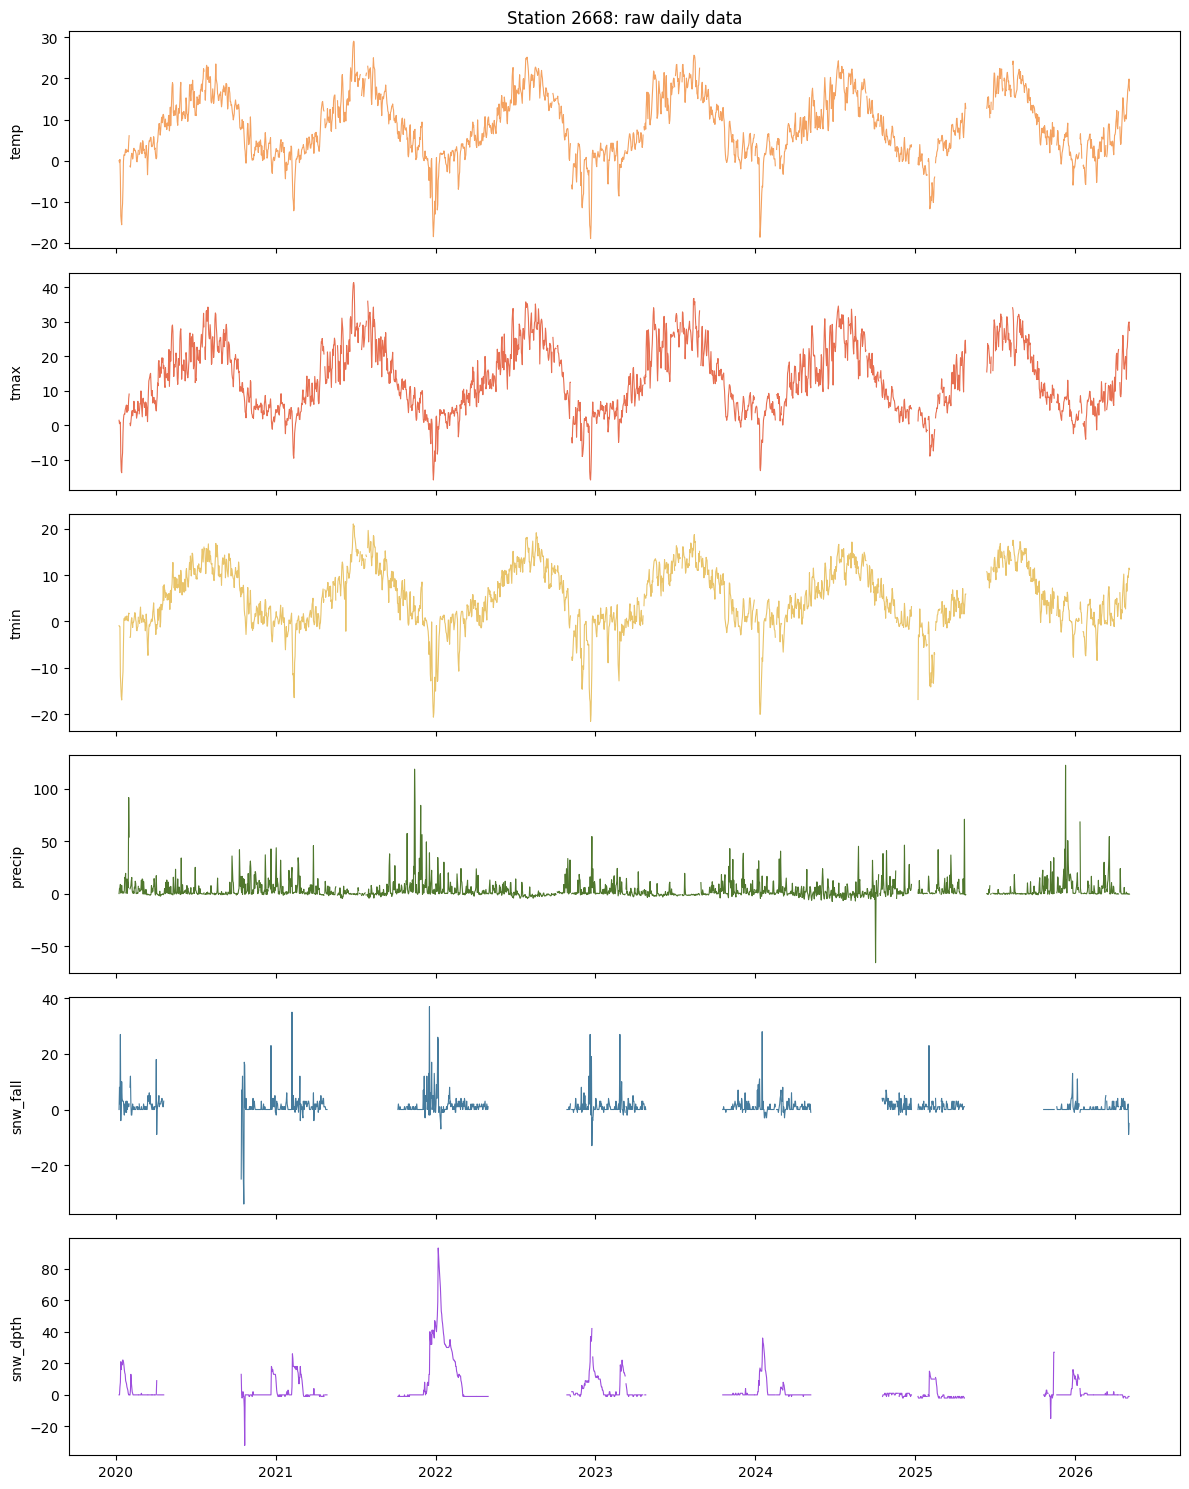

Index(['temp', 'tmin', 'tmax', 'precip', 'snw_fall', 'snw_dpth'], dtype='str')


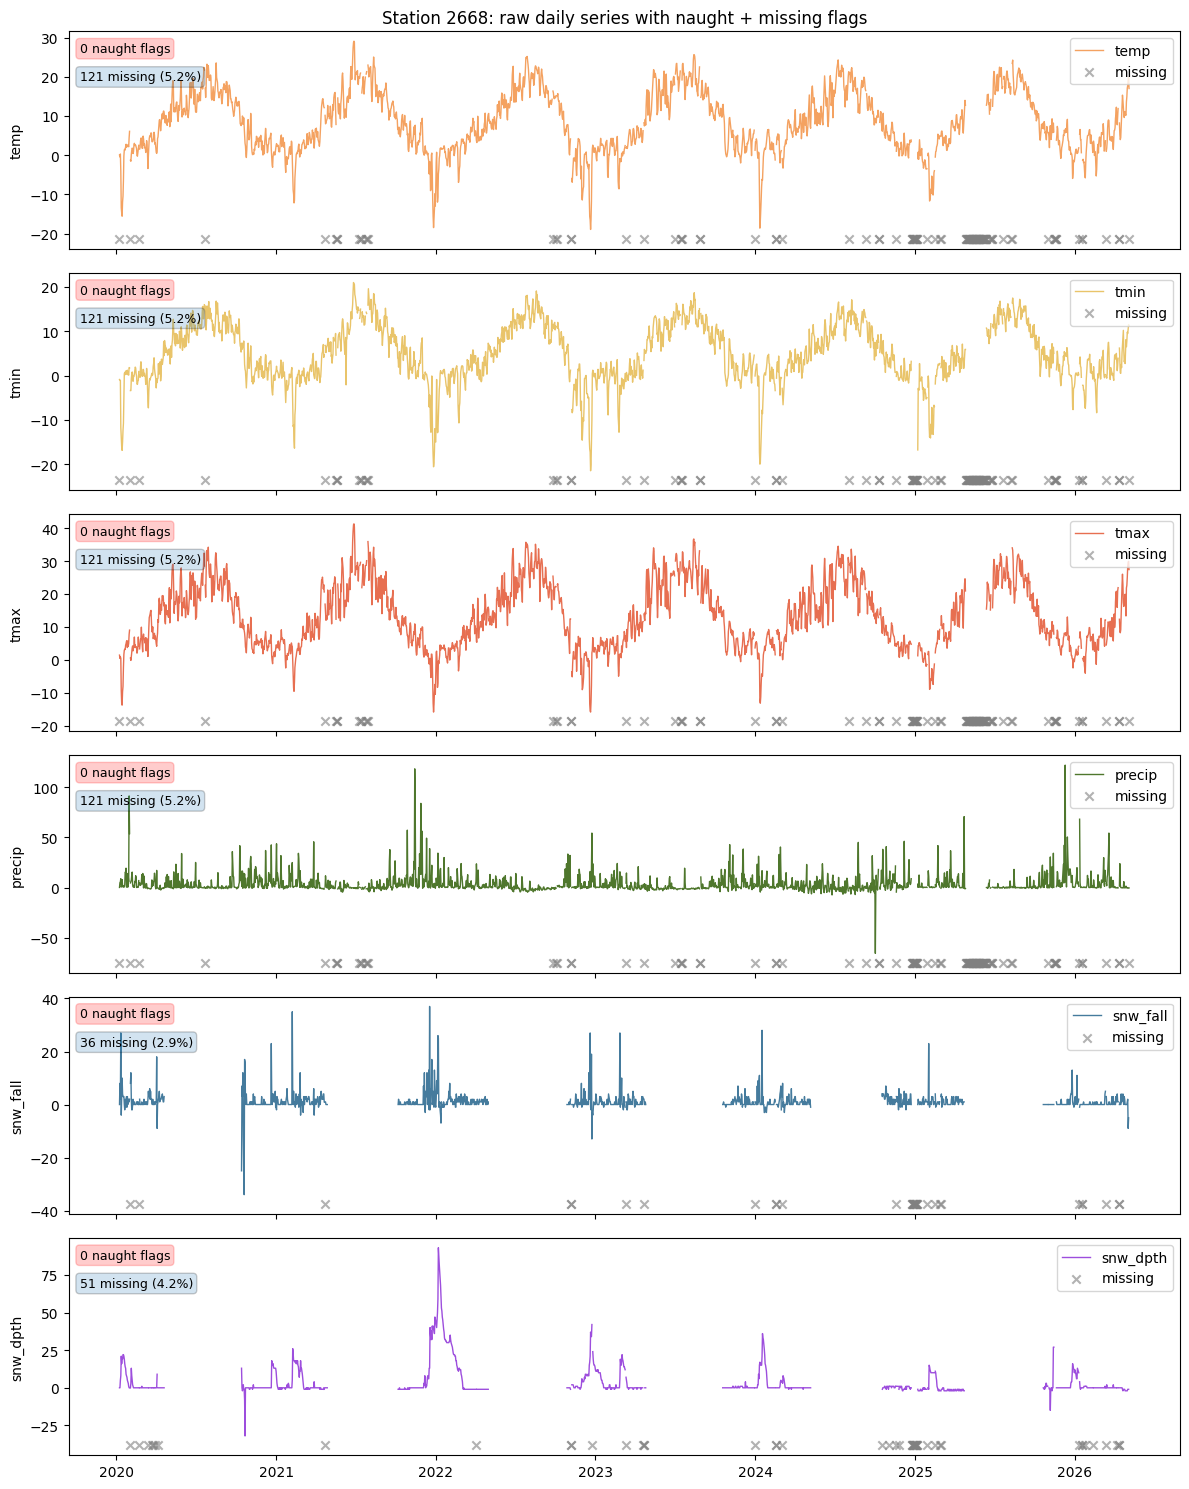

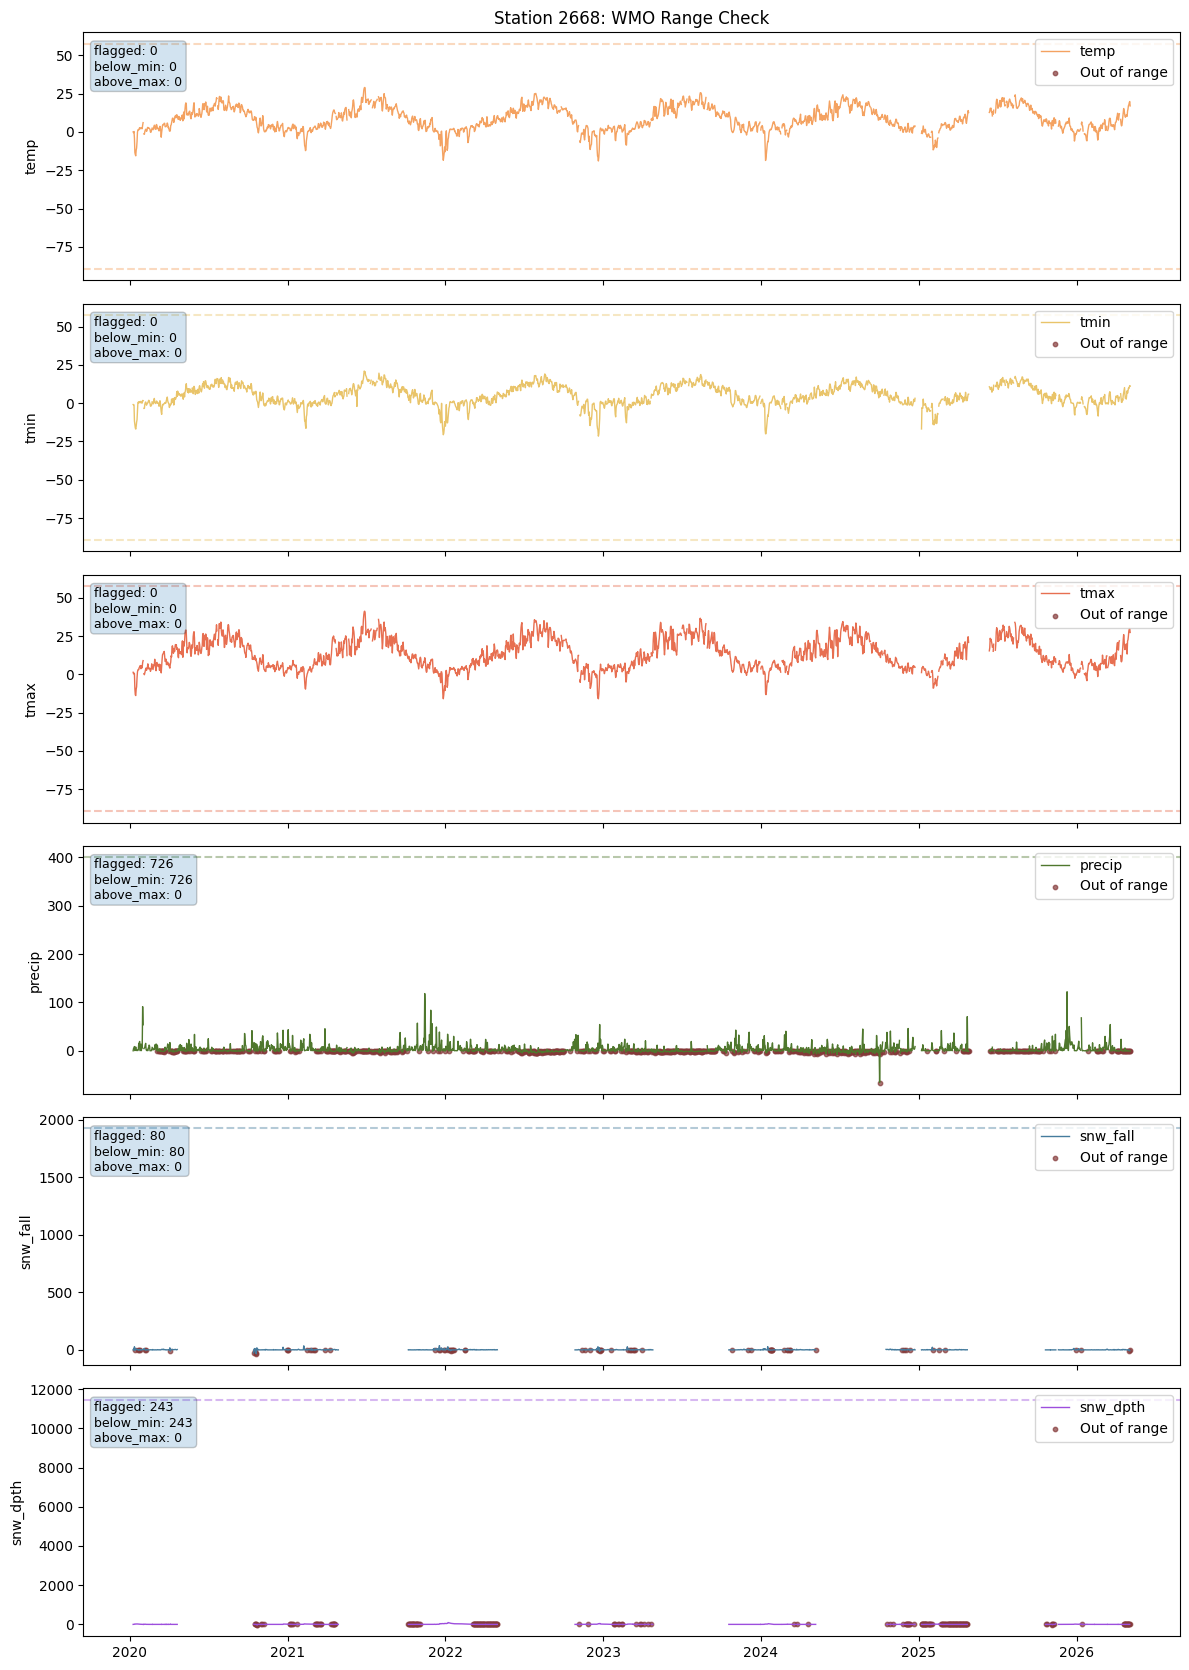

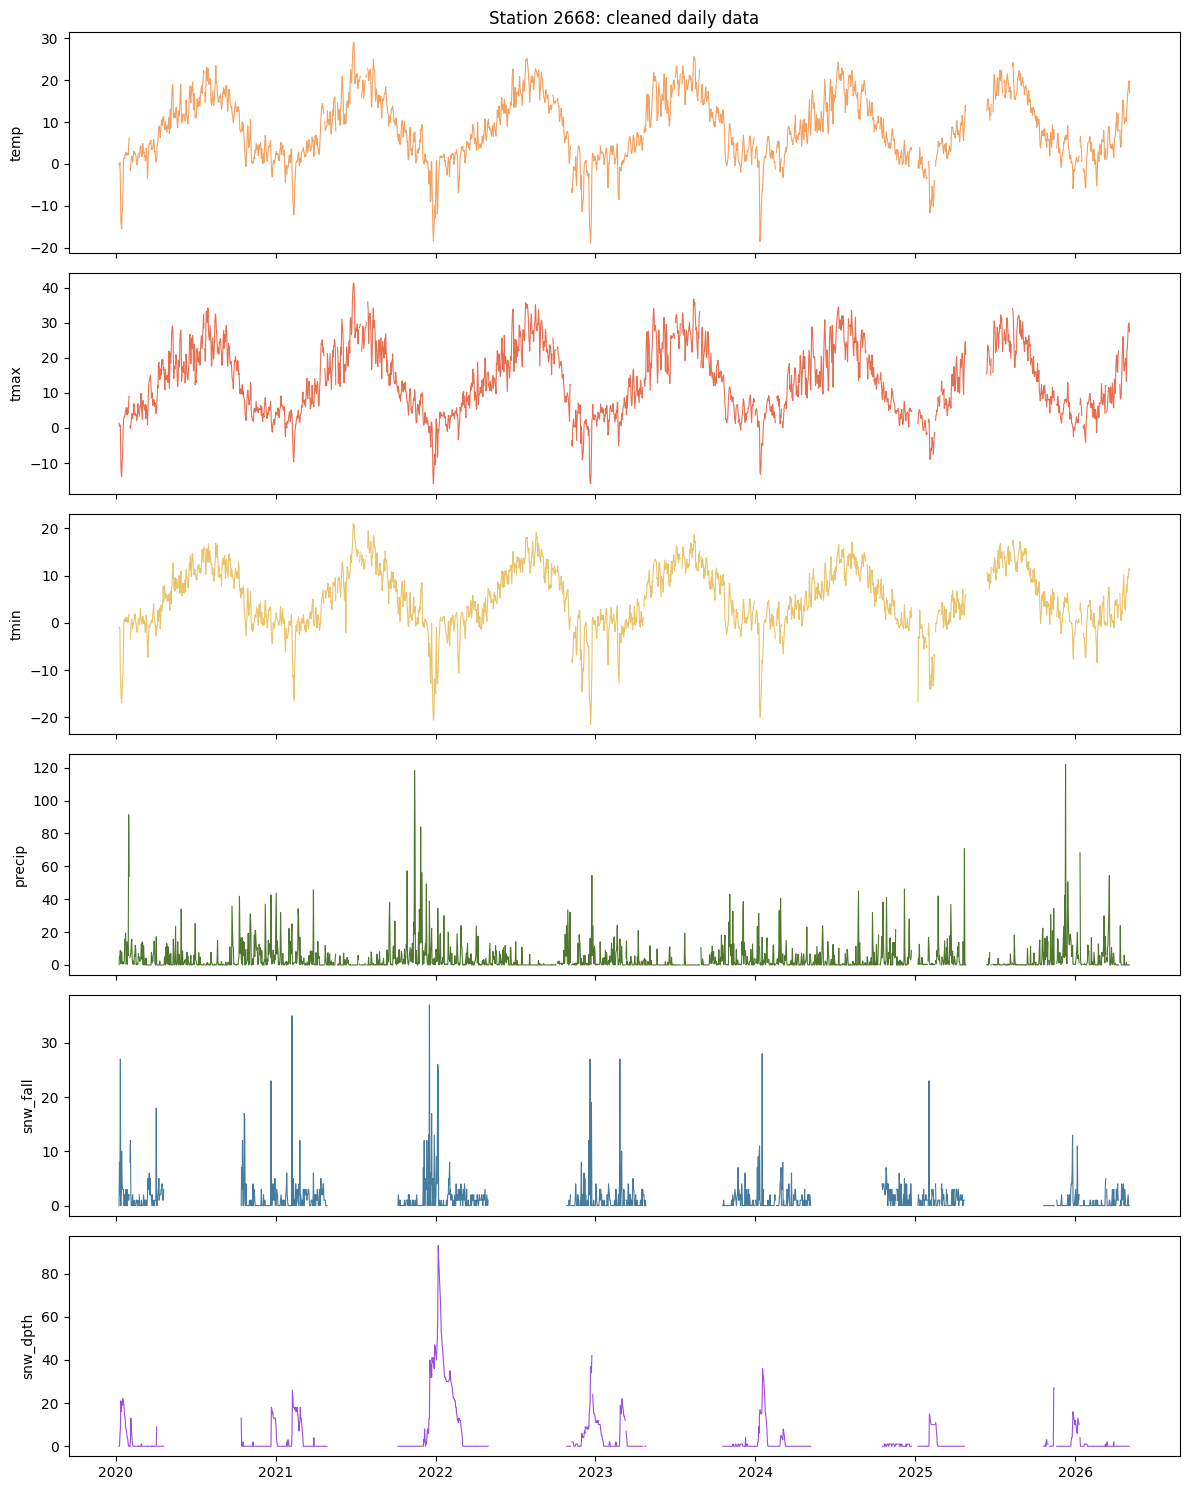

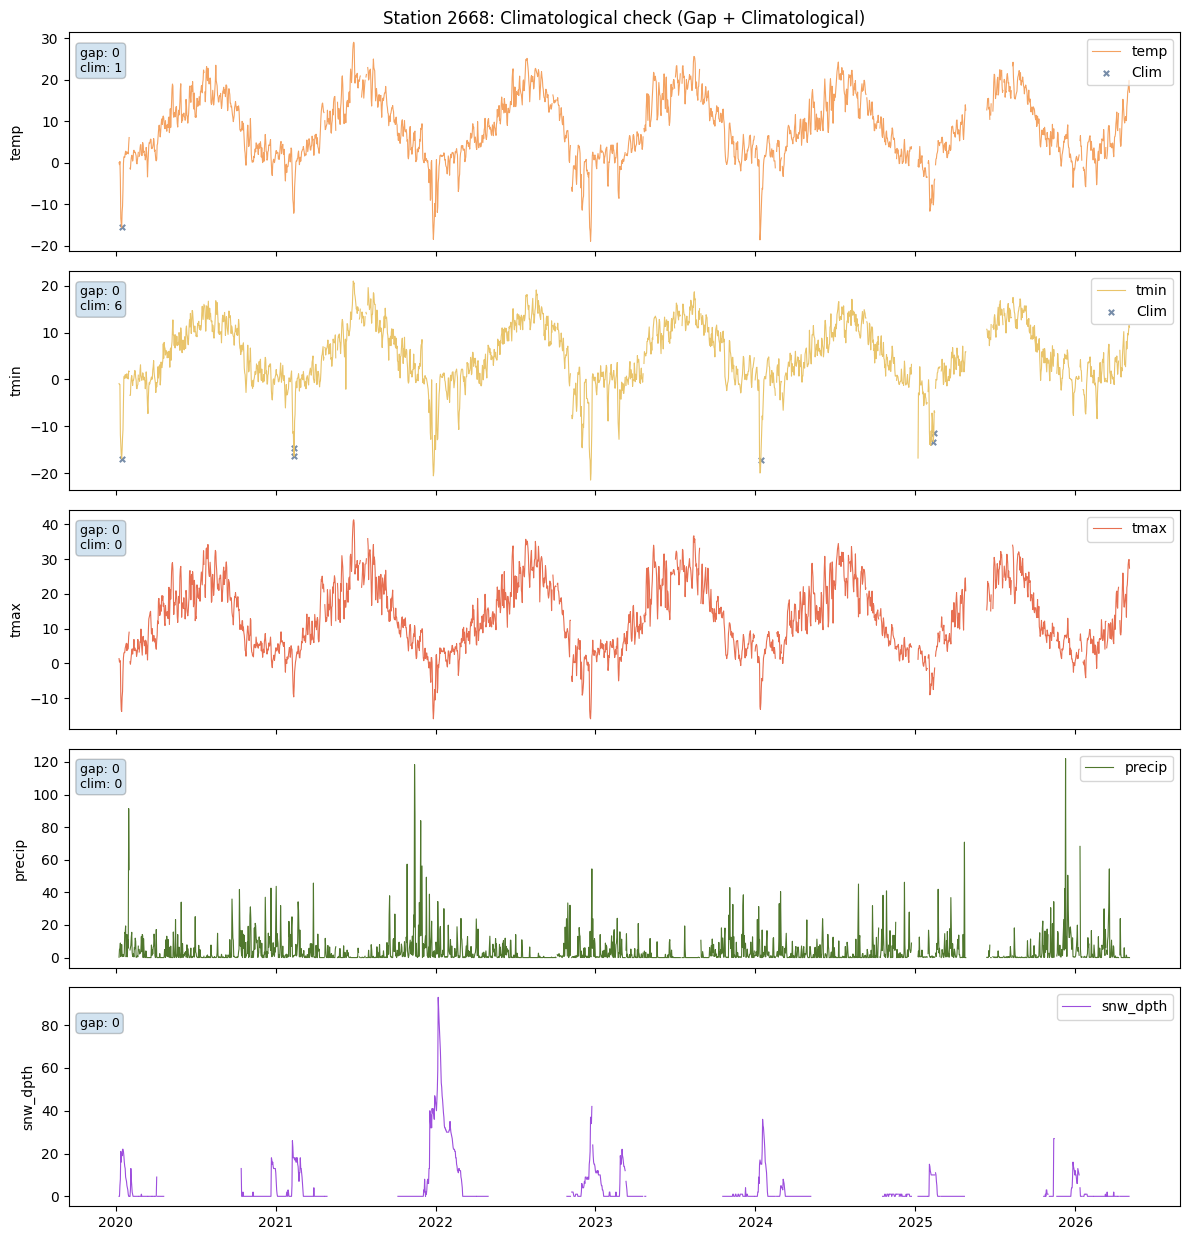

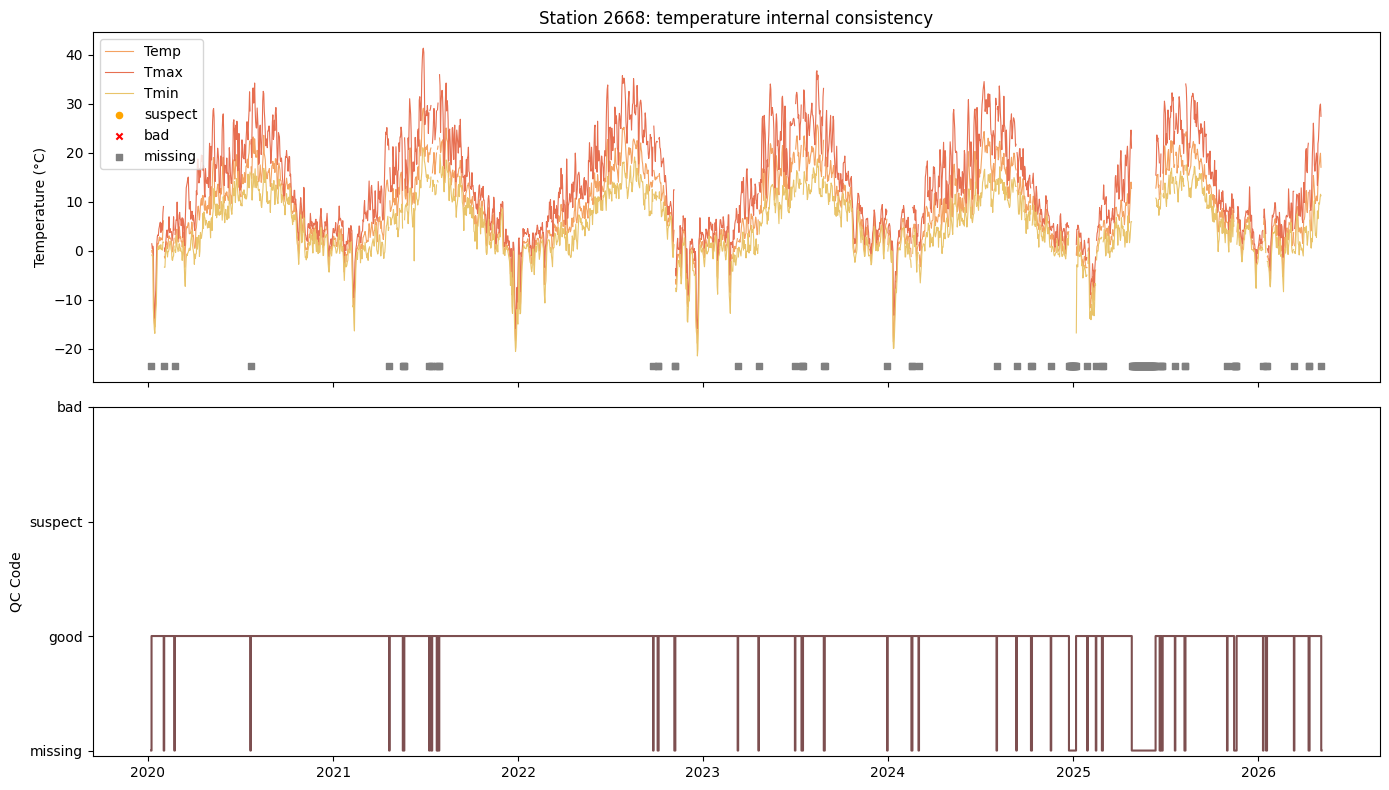

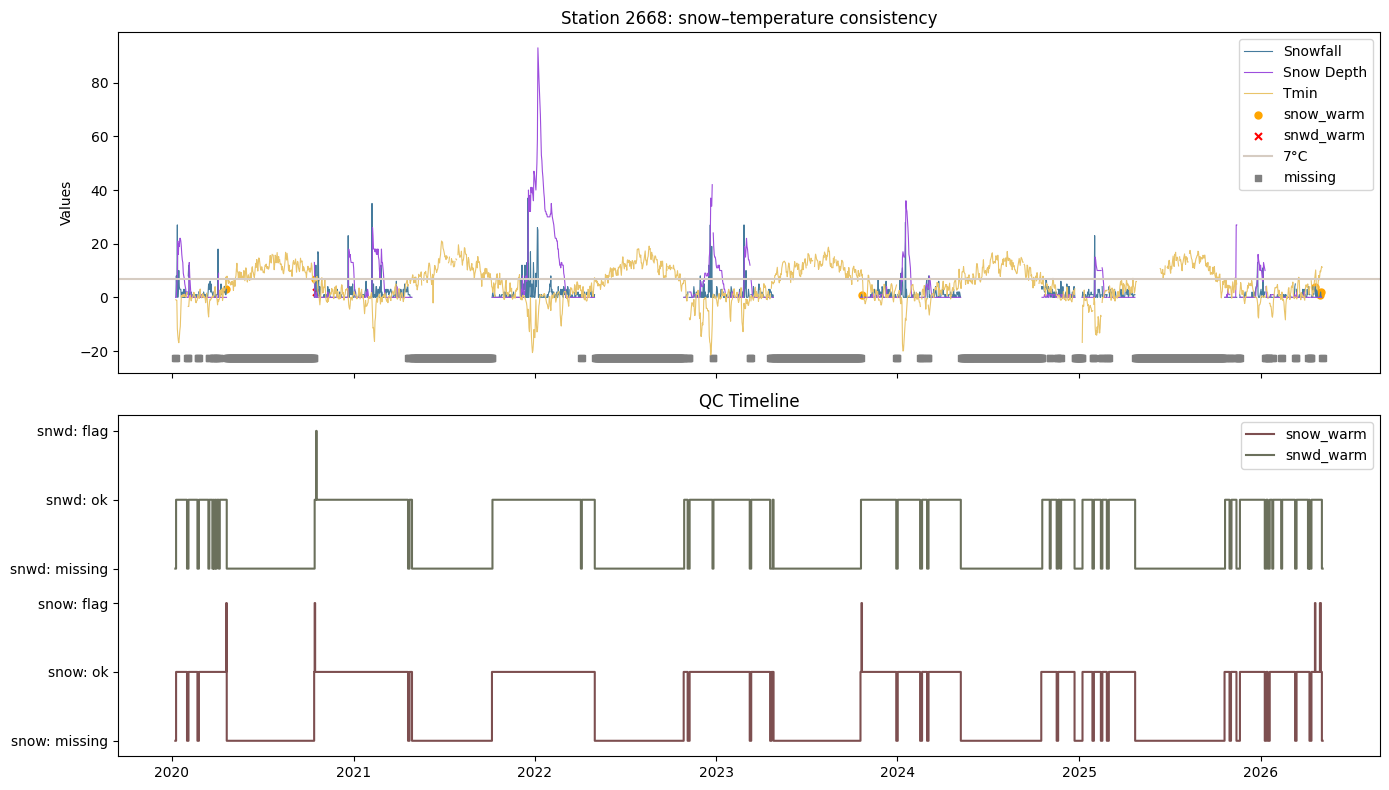

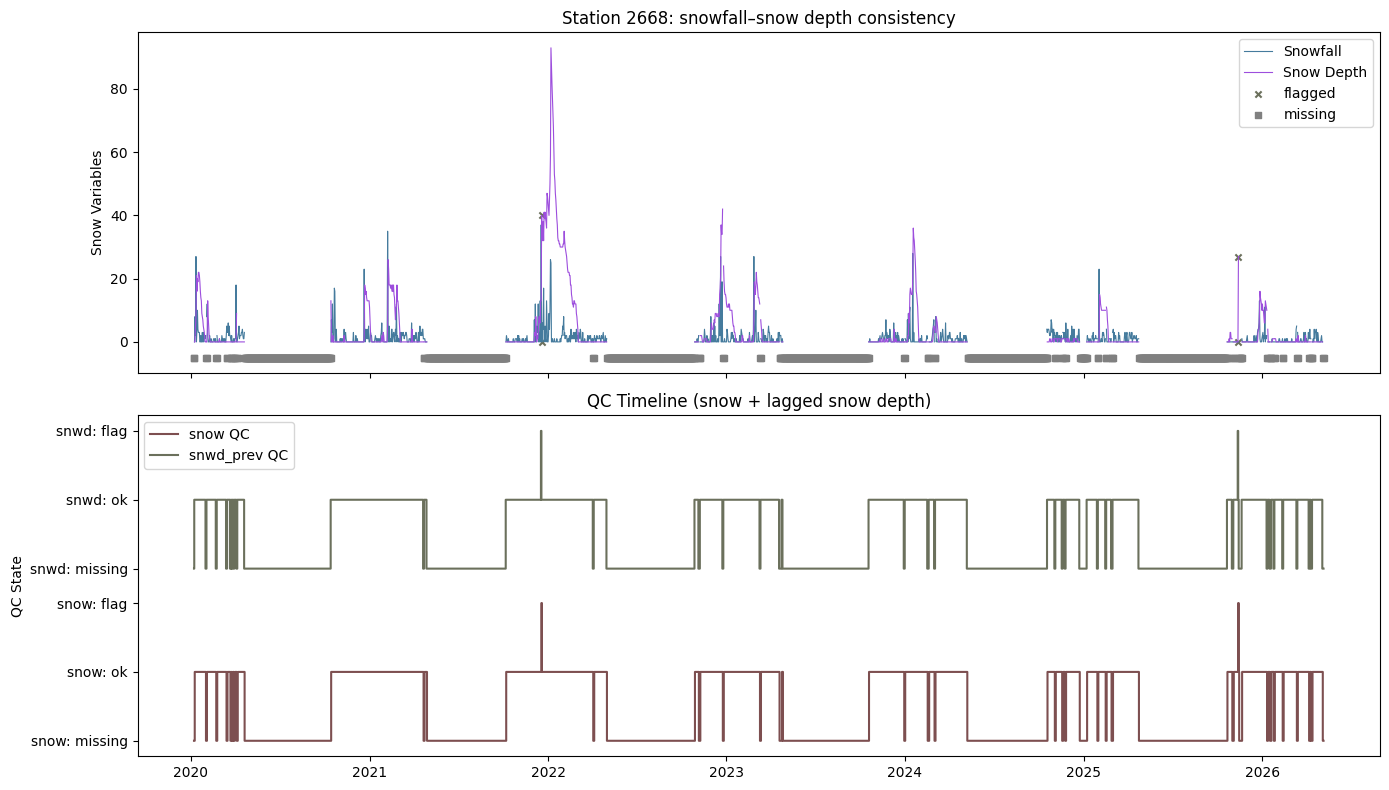

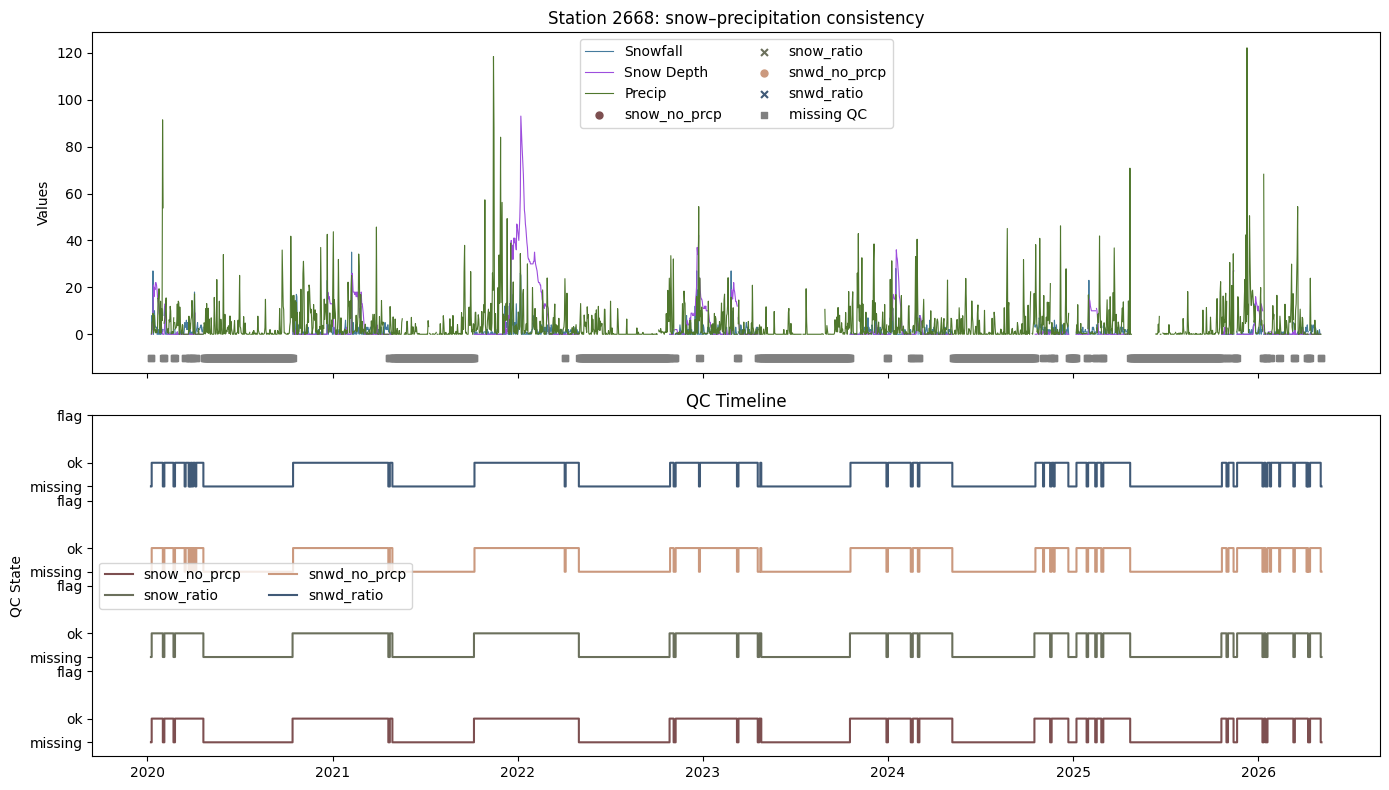

Station 2794


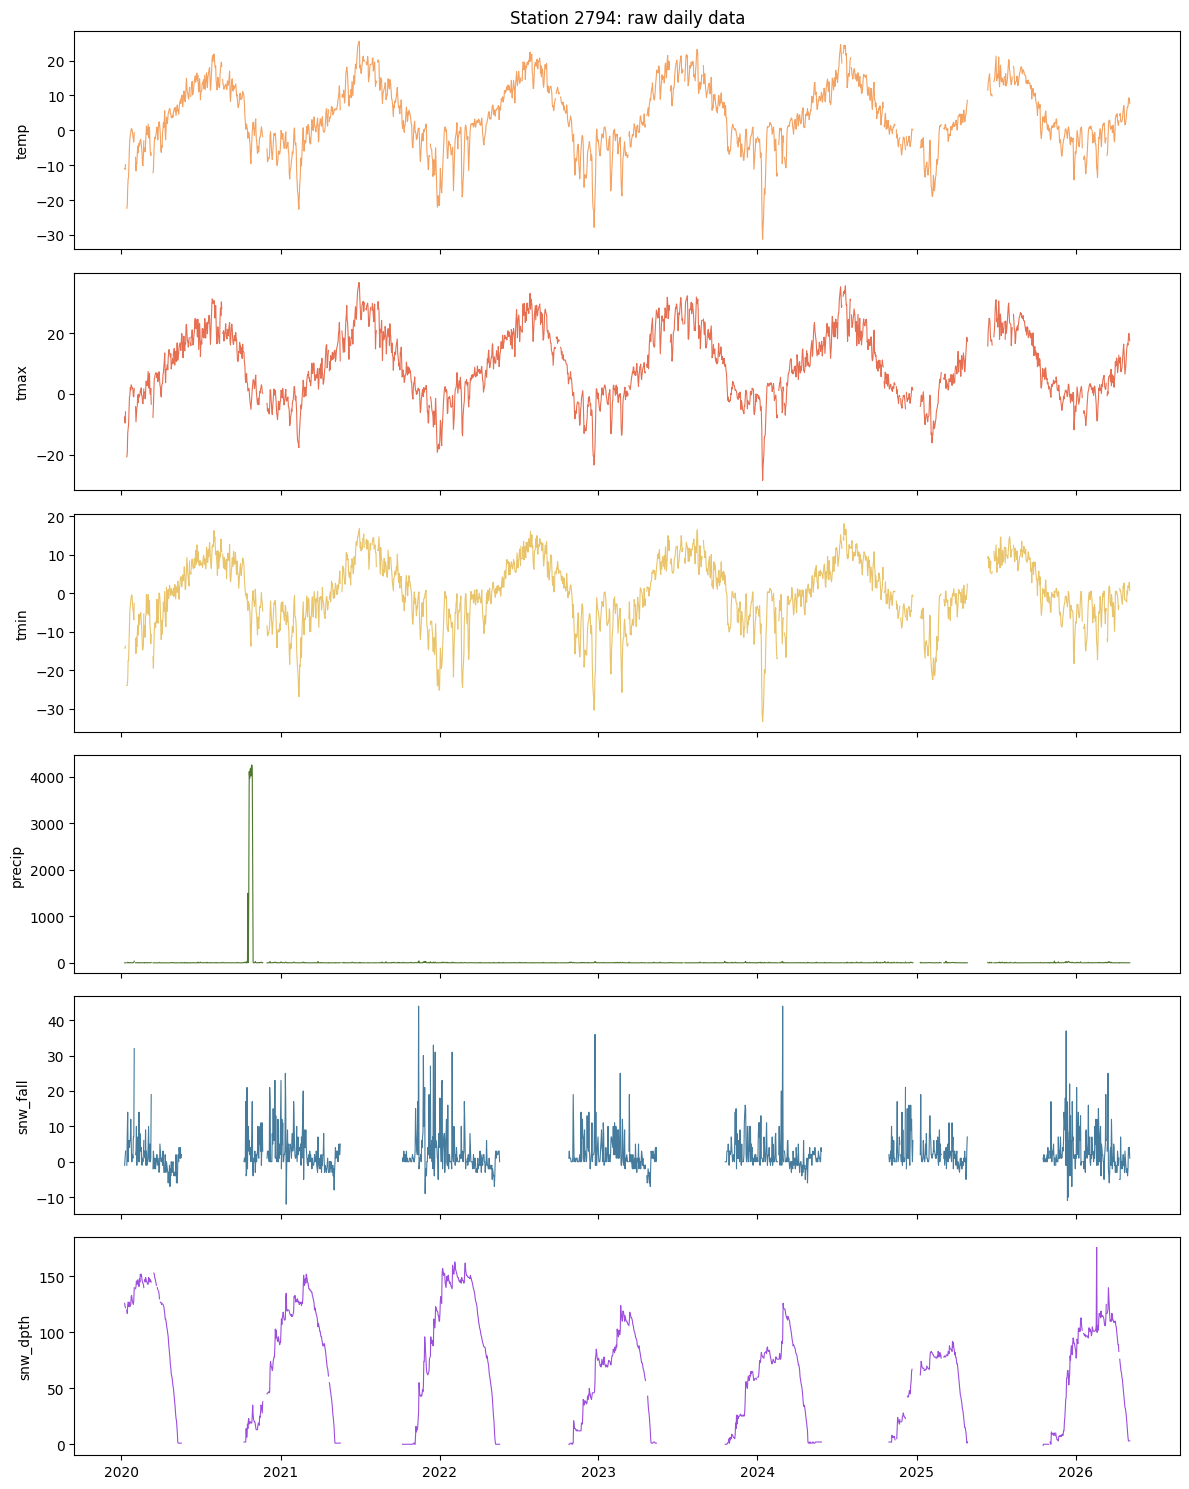

Index(['temp', 'tmin', 'tmax', 'precip', 'snw_fall', 'snw_dpth'], dtype='str')


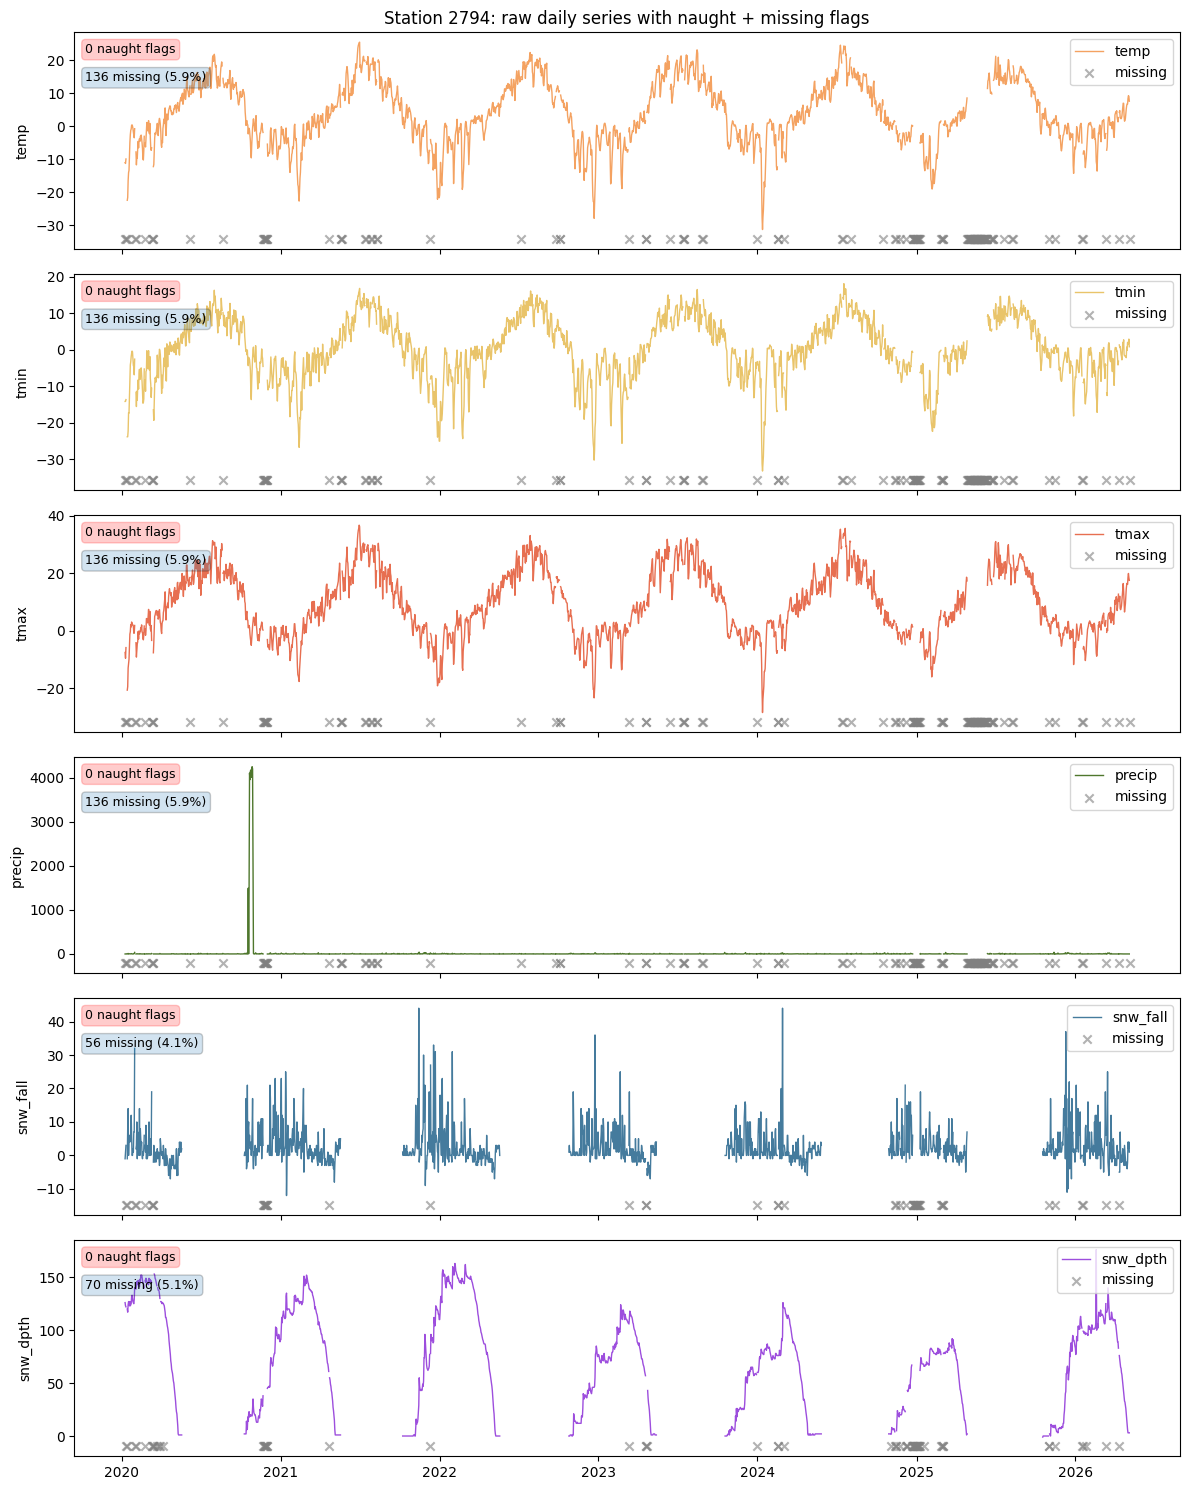

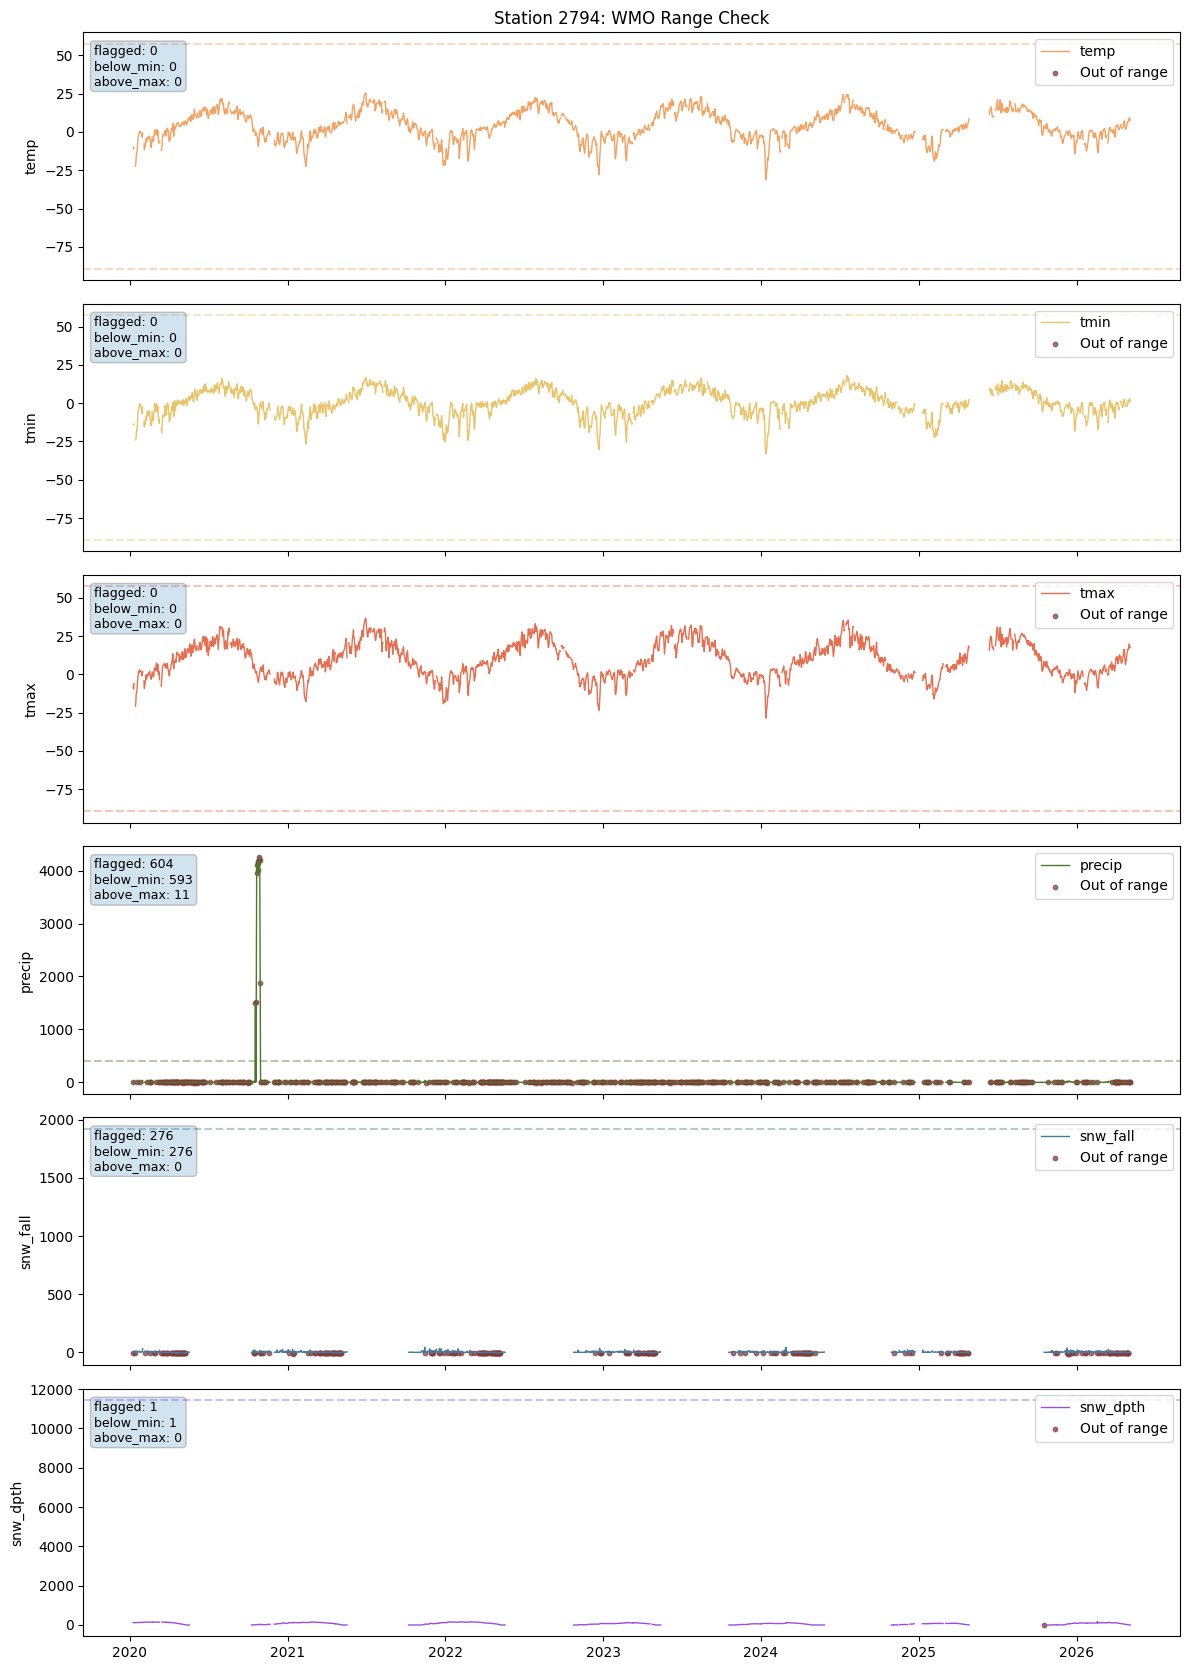

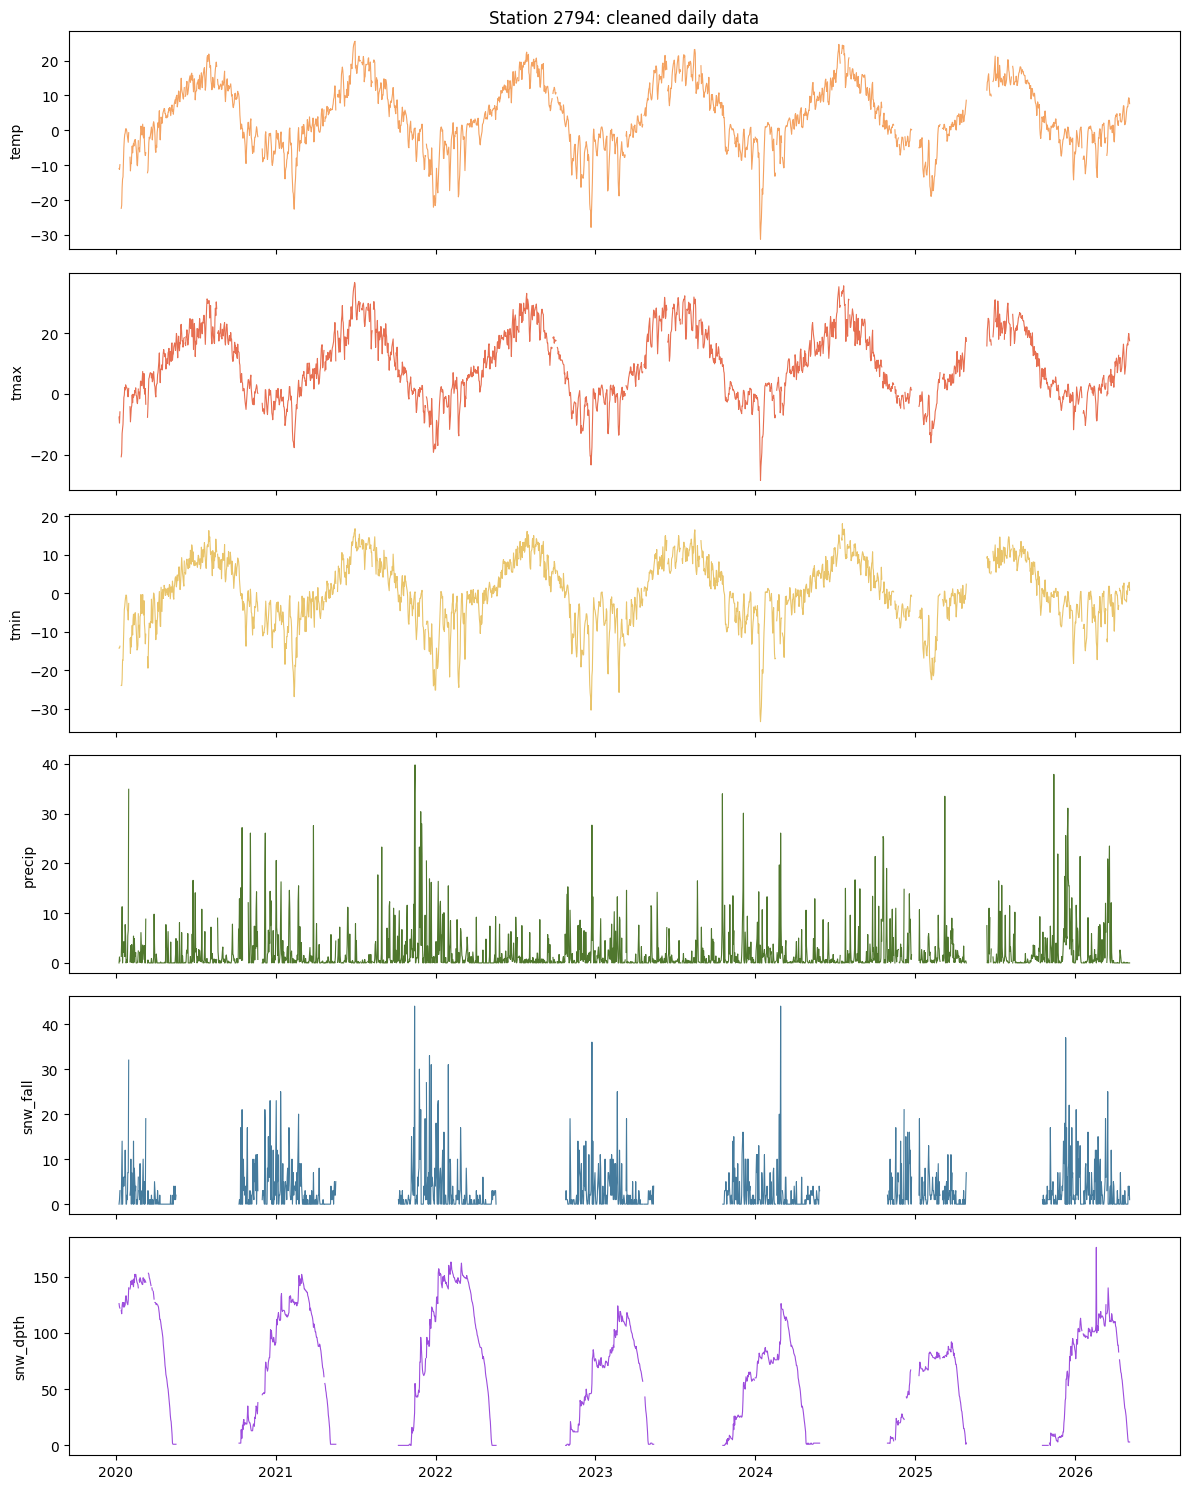

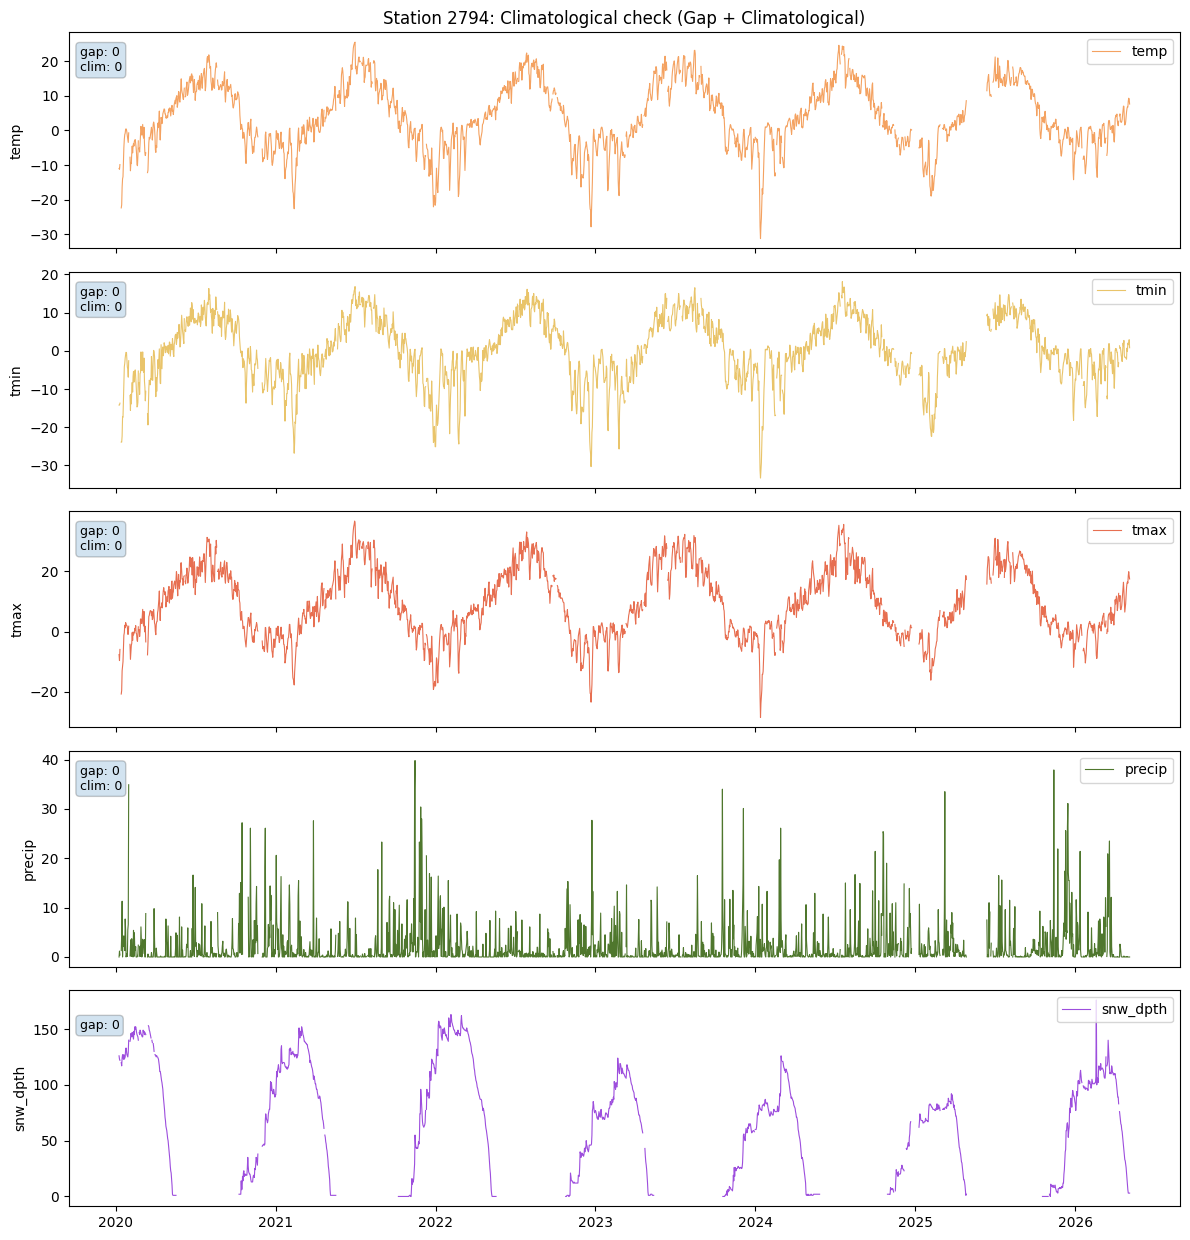

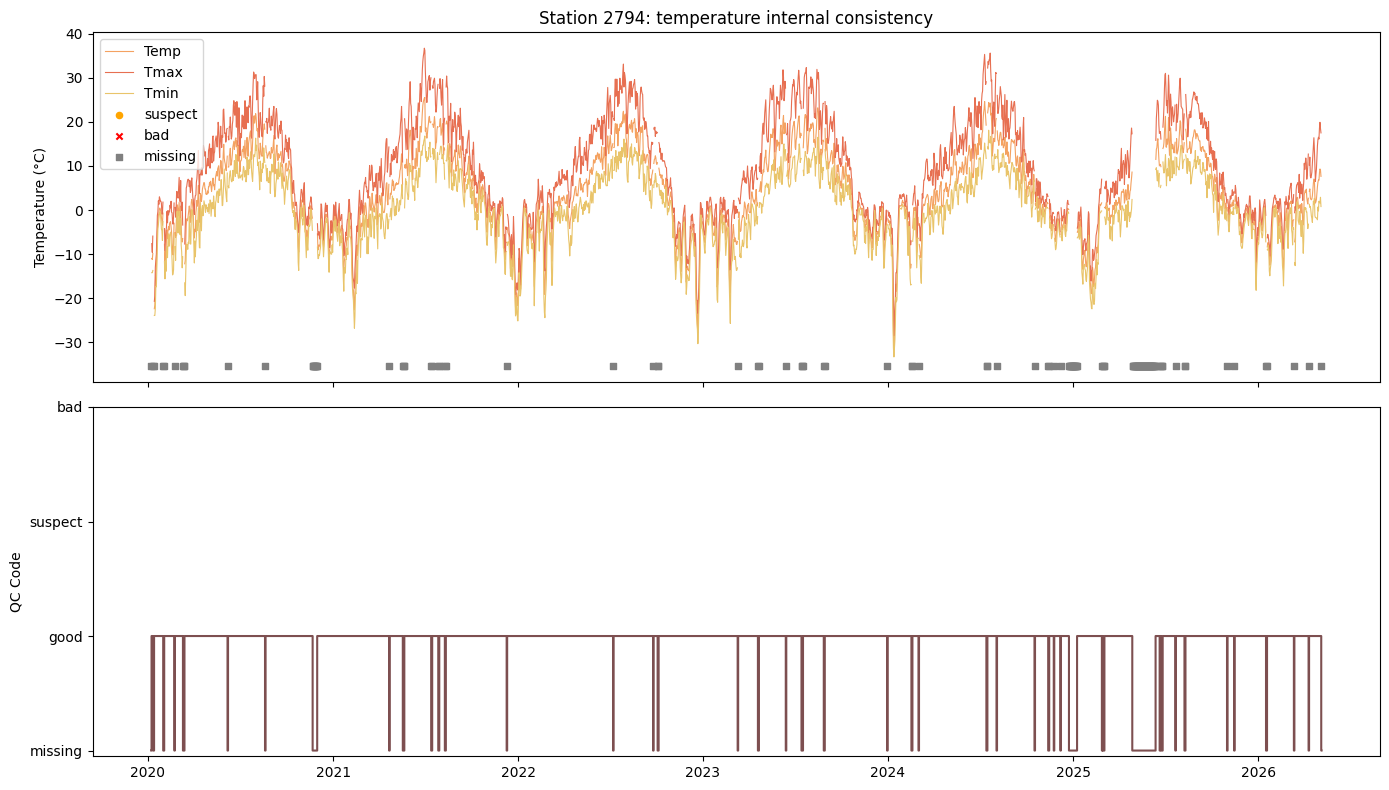

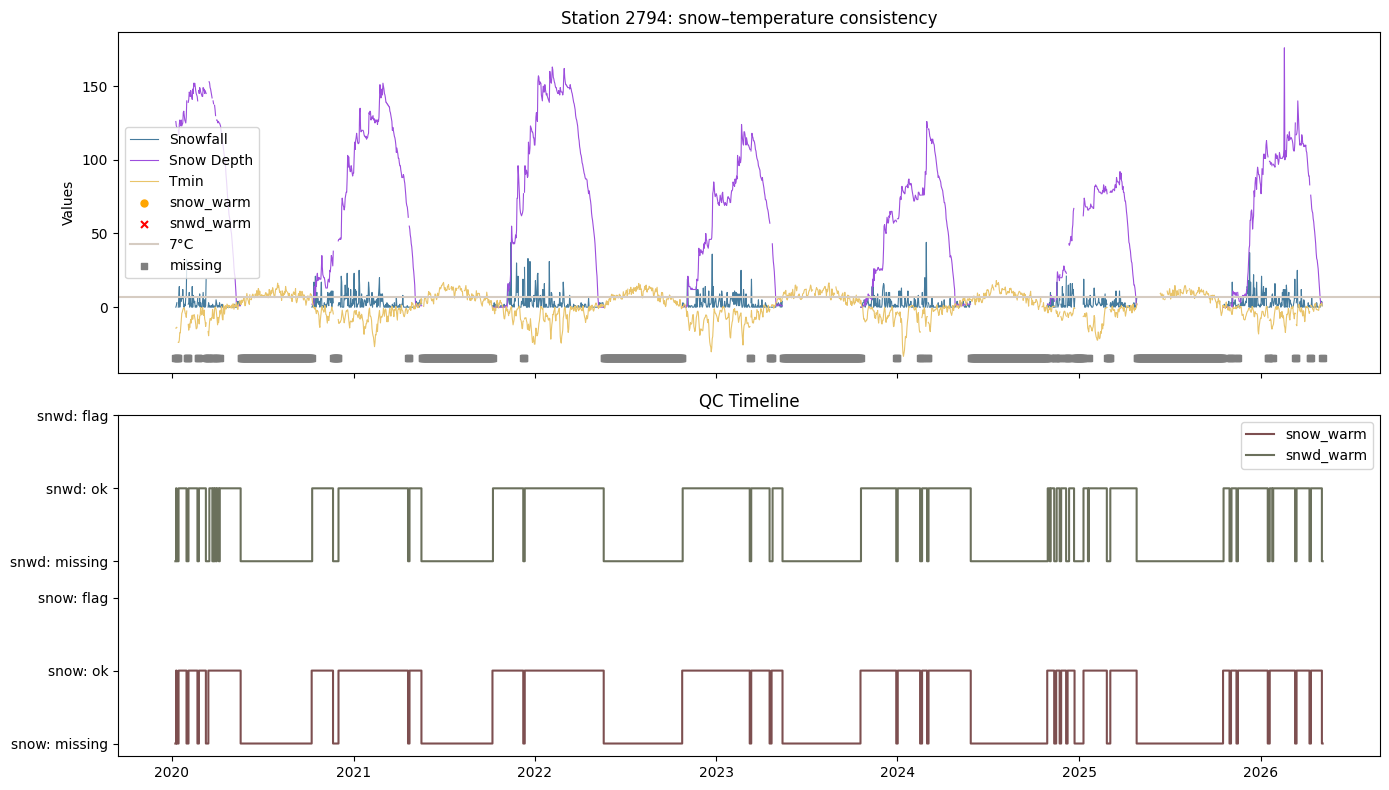

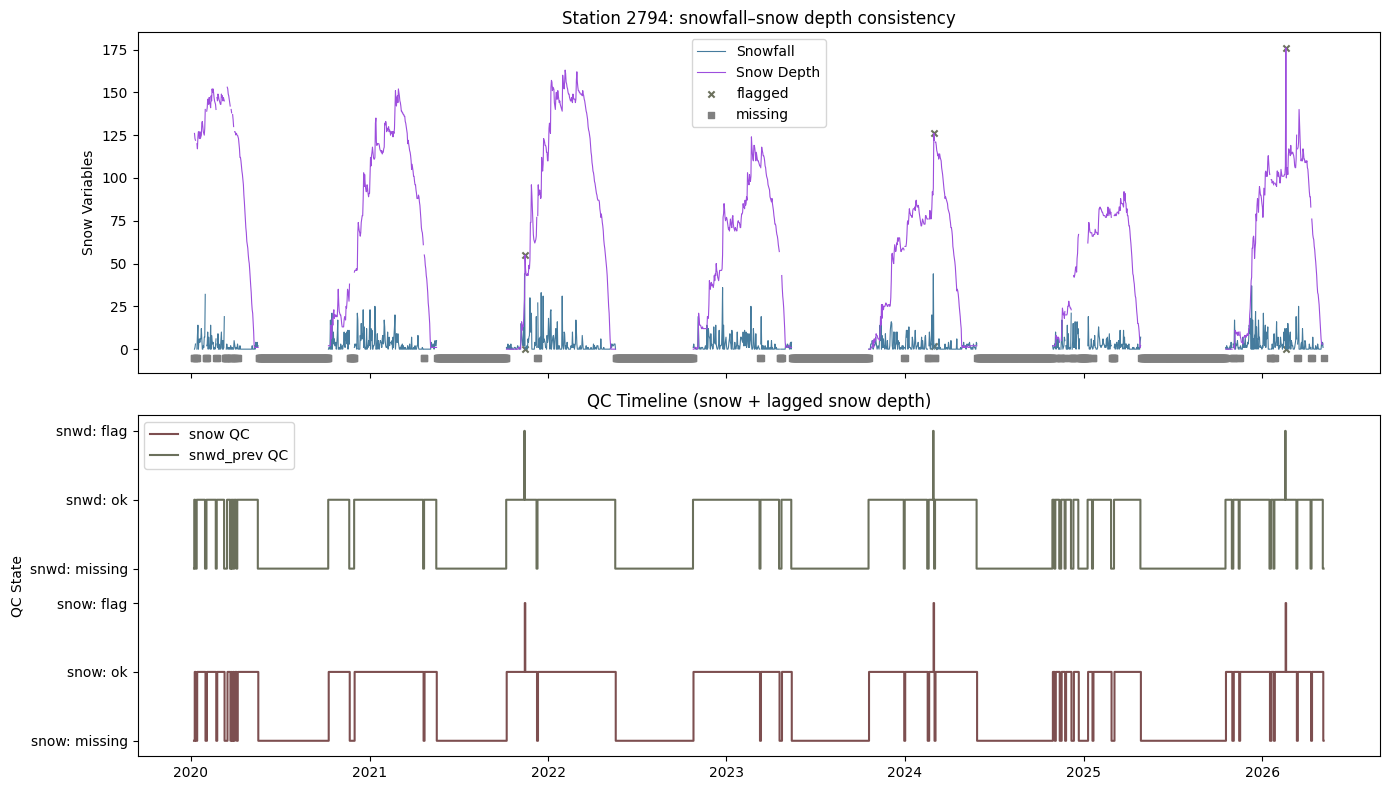

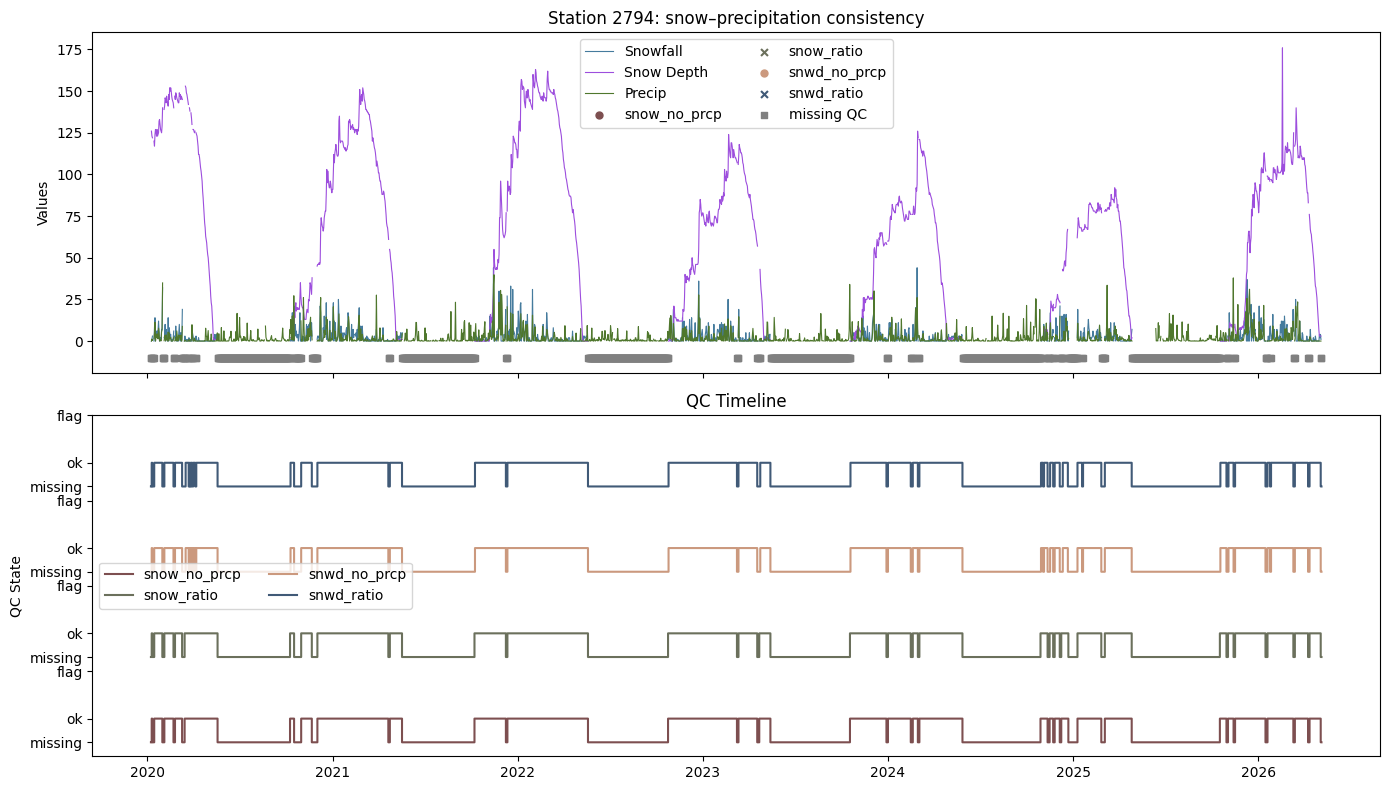

Station 2955


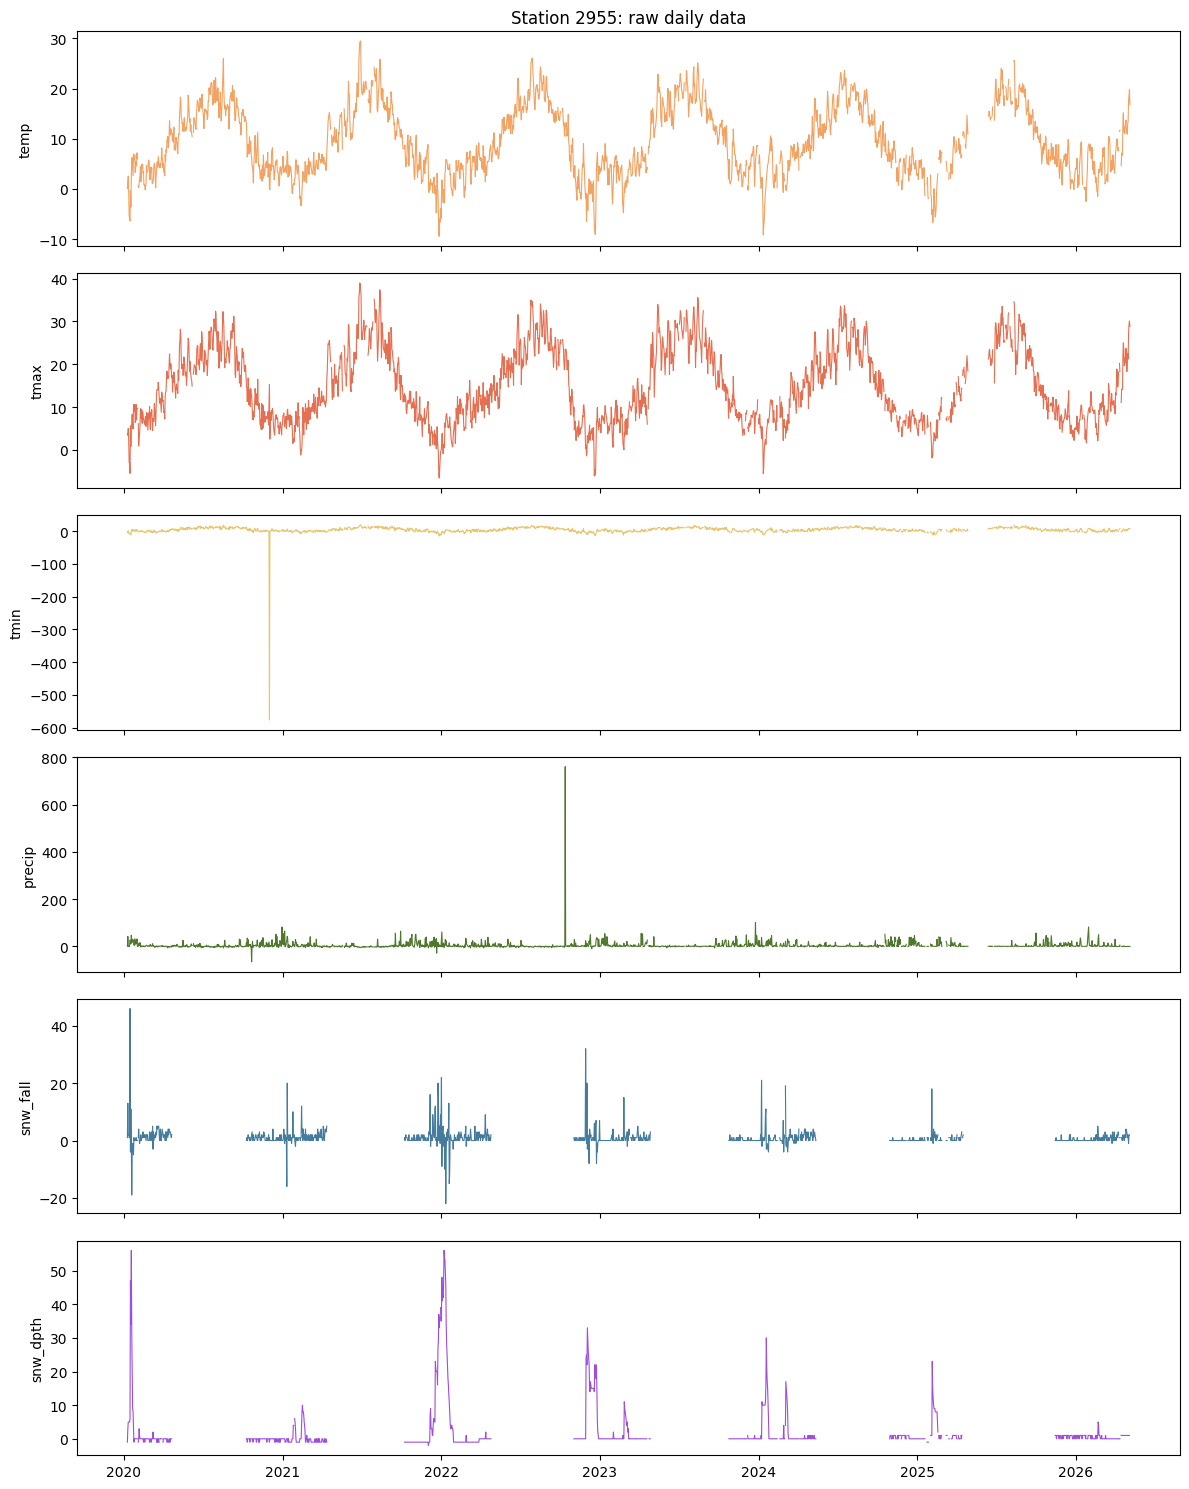

Index(['temp', 'tmin', 'tmax', 'precip', 'snw_fall', 'snw_dpth'], dtype='str')


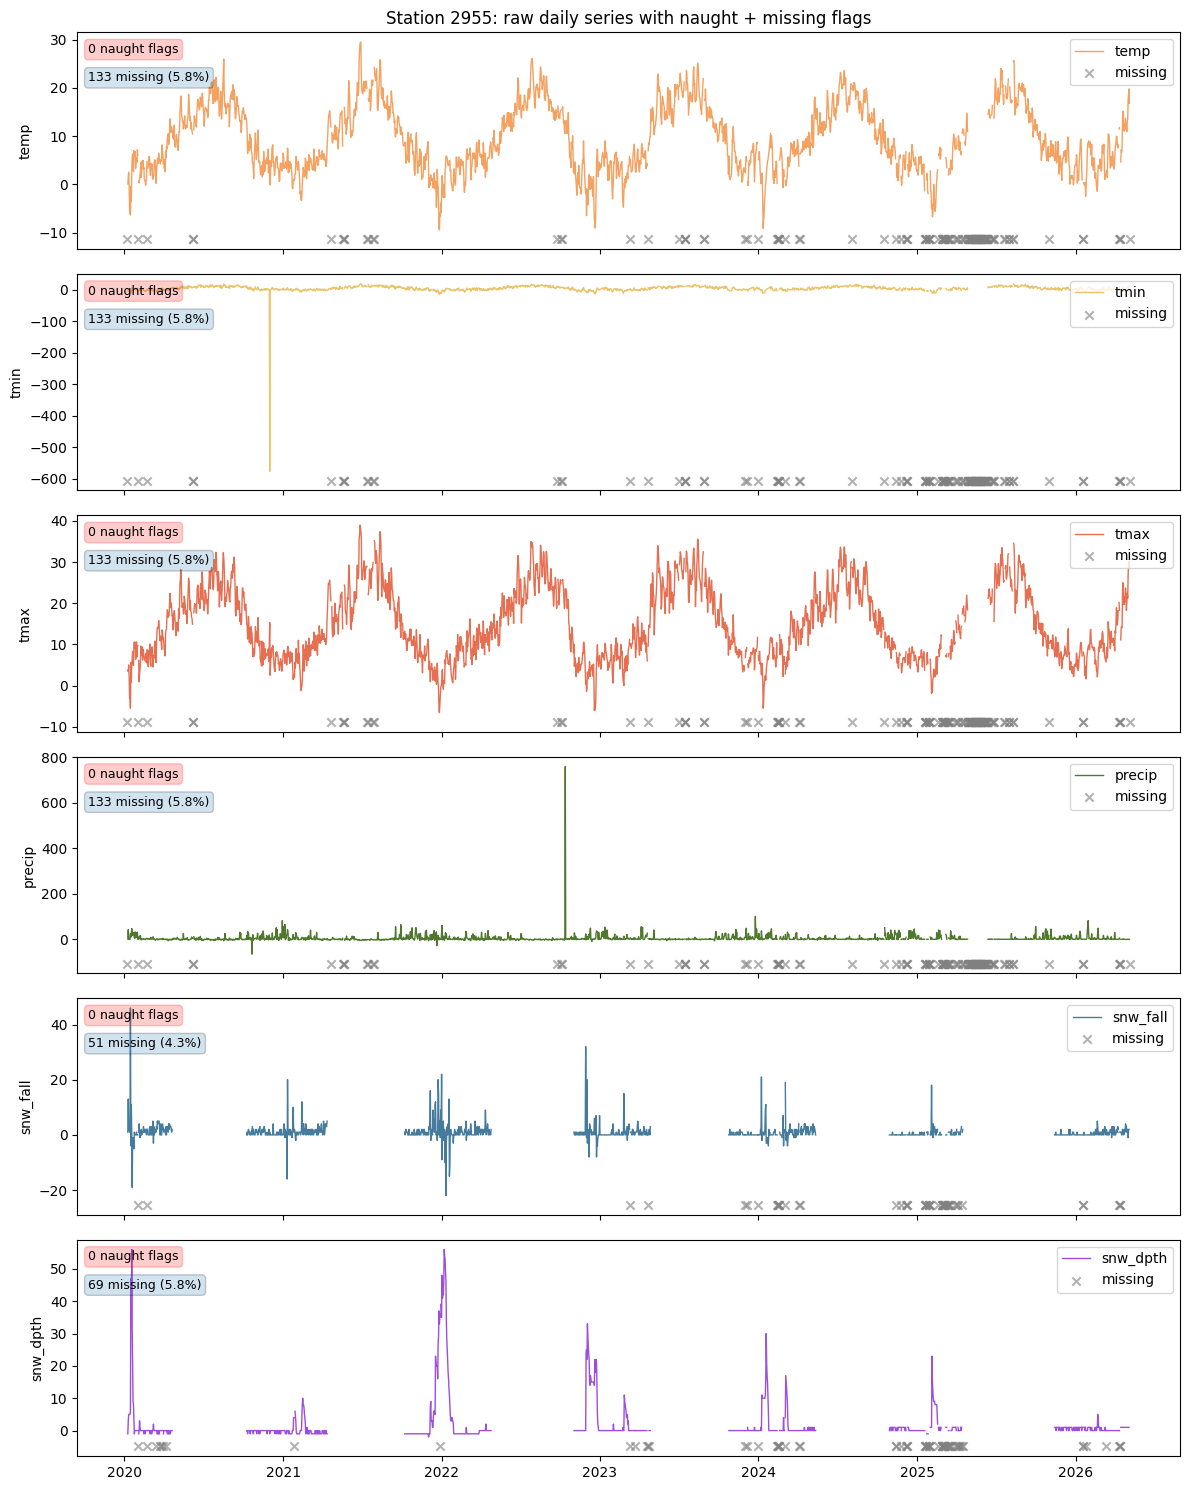

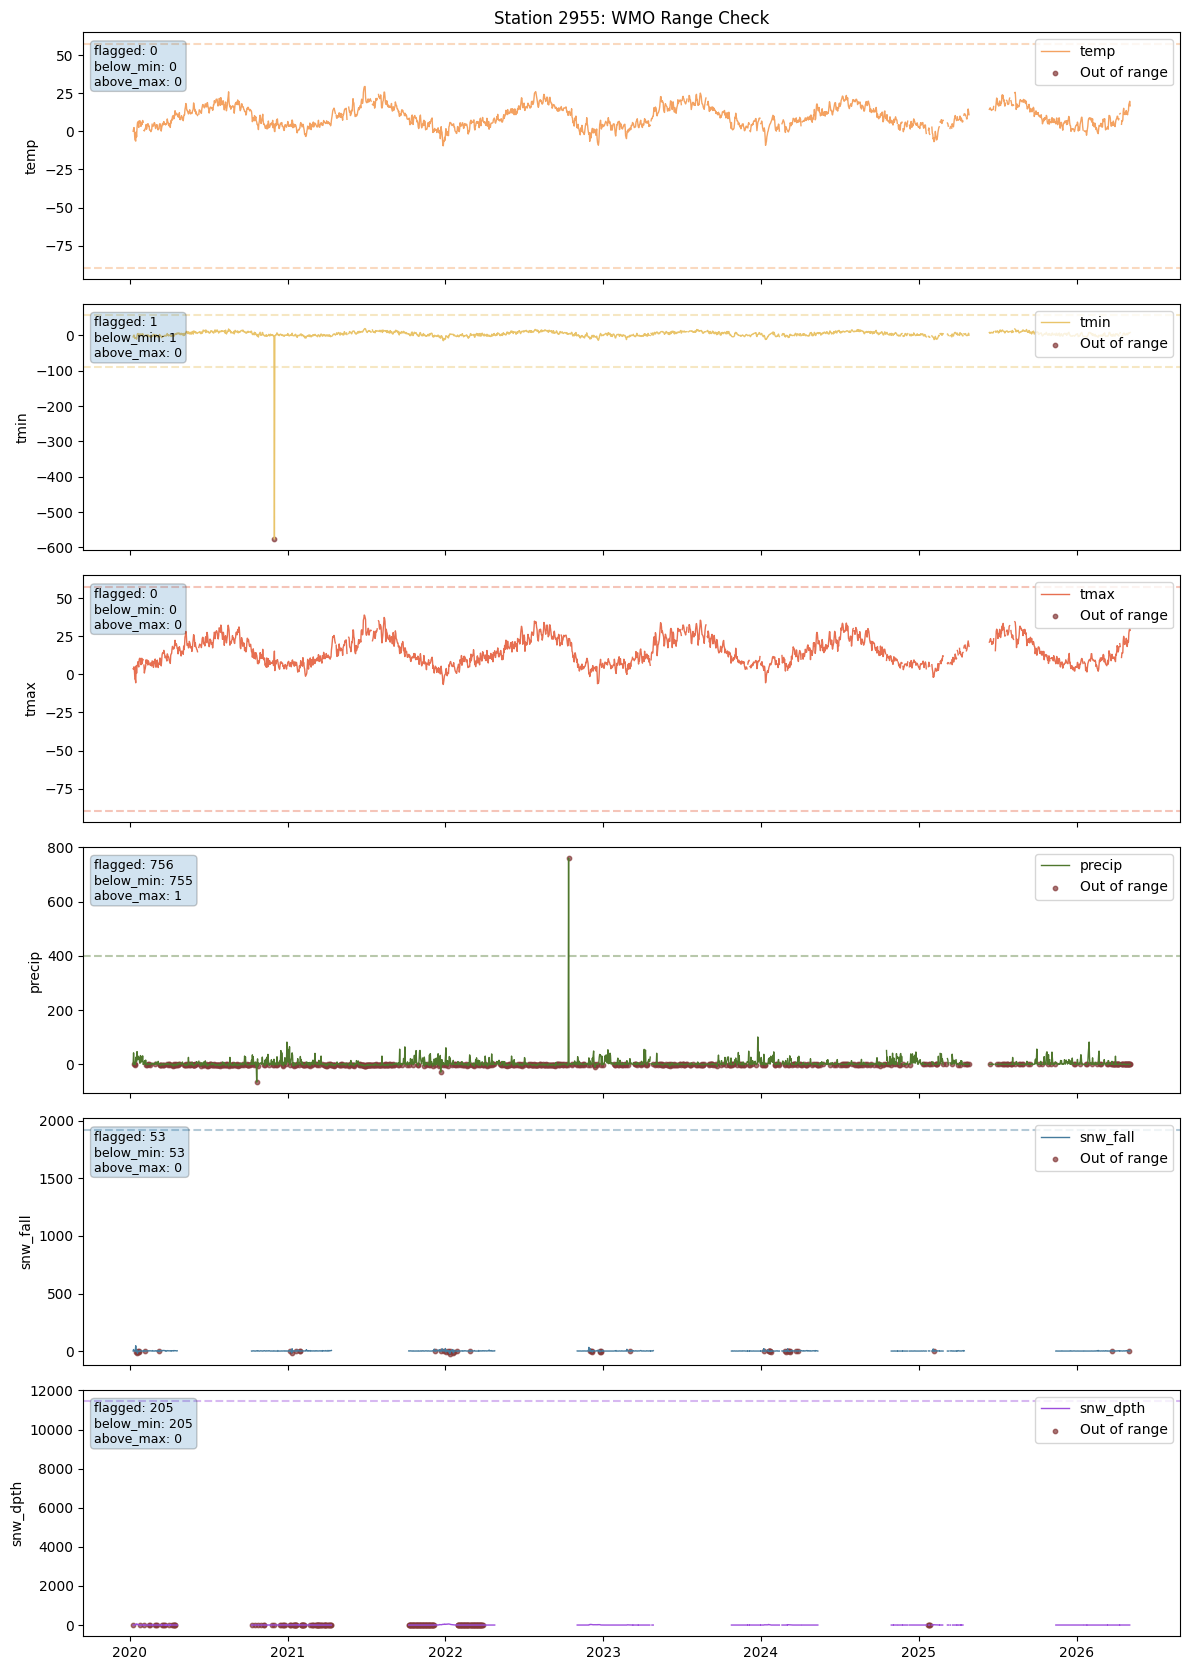

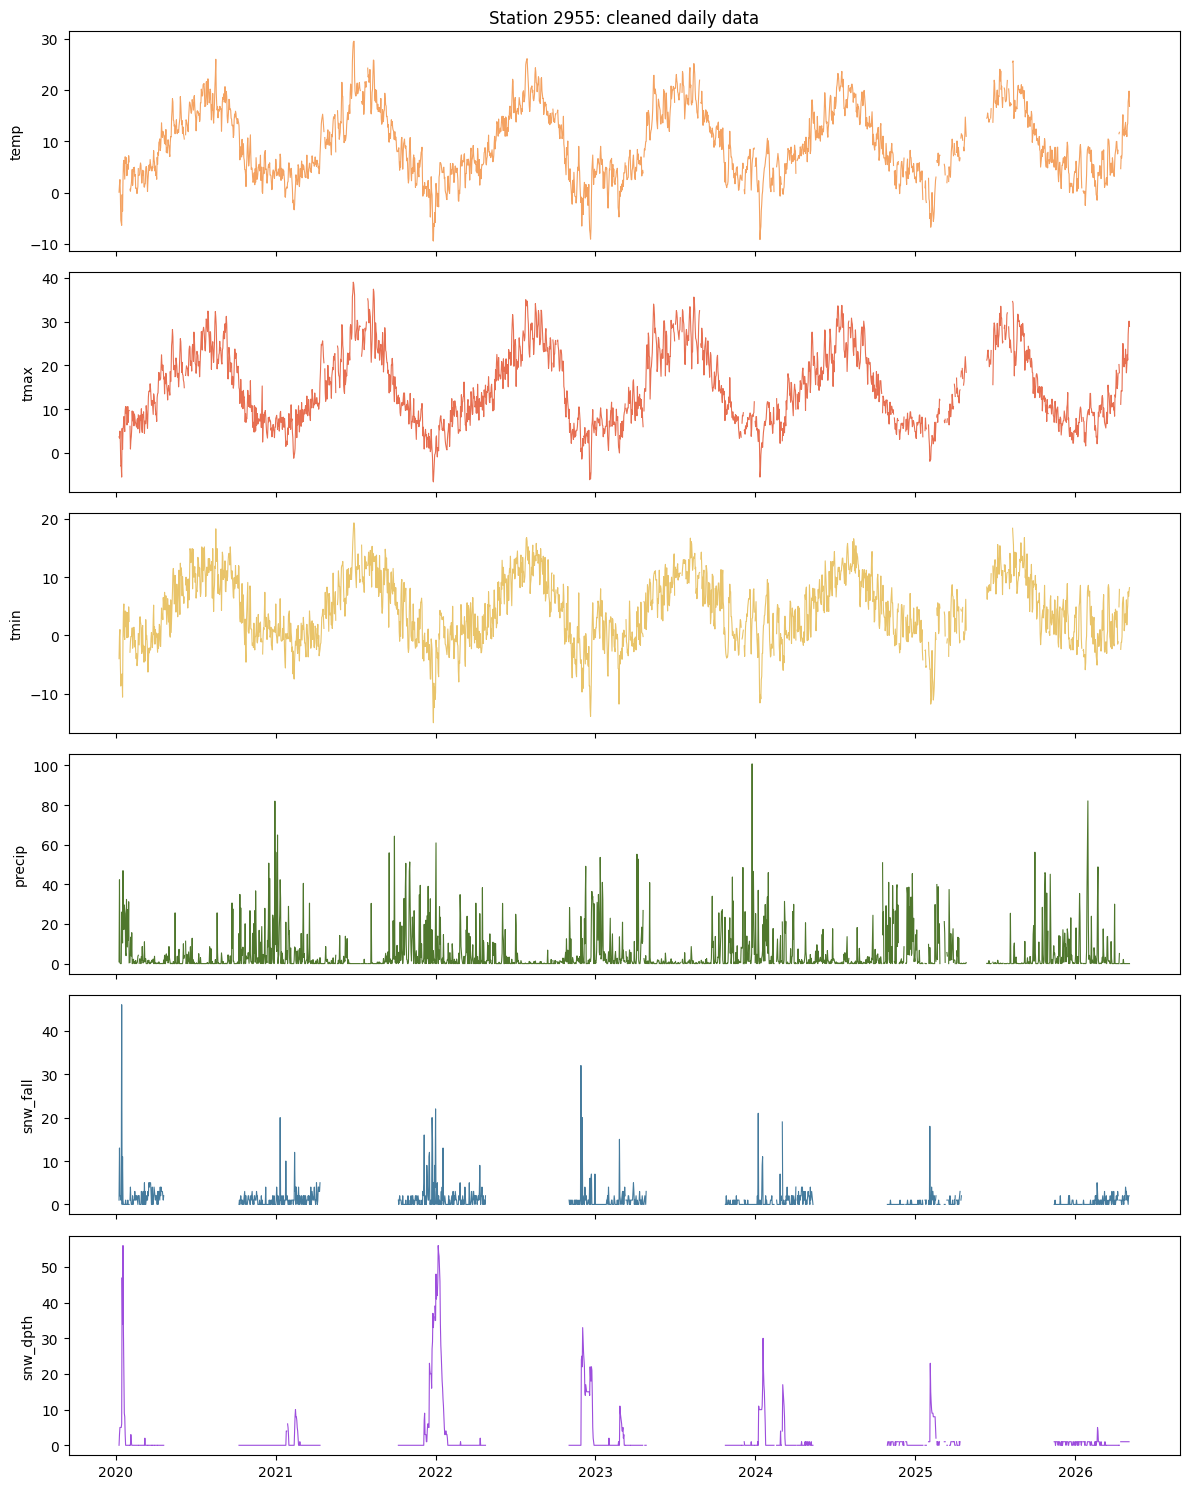

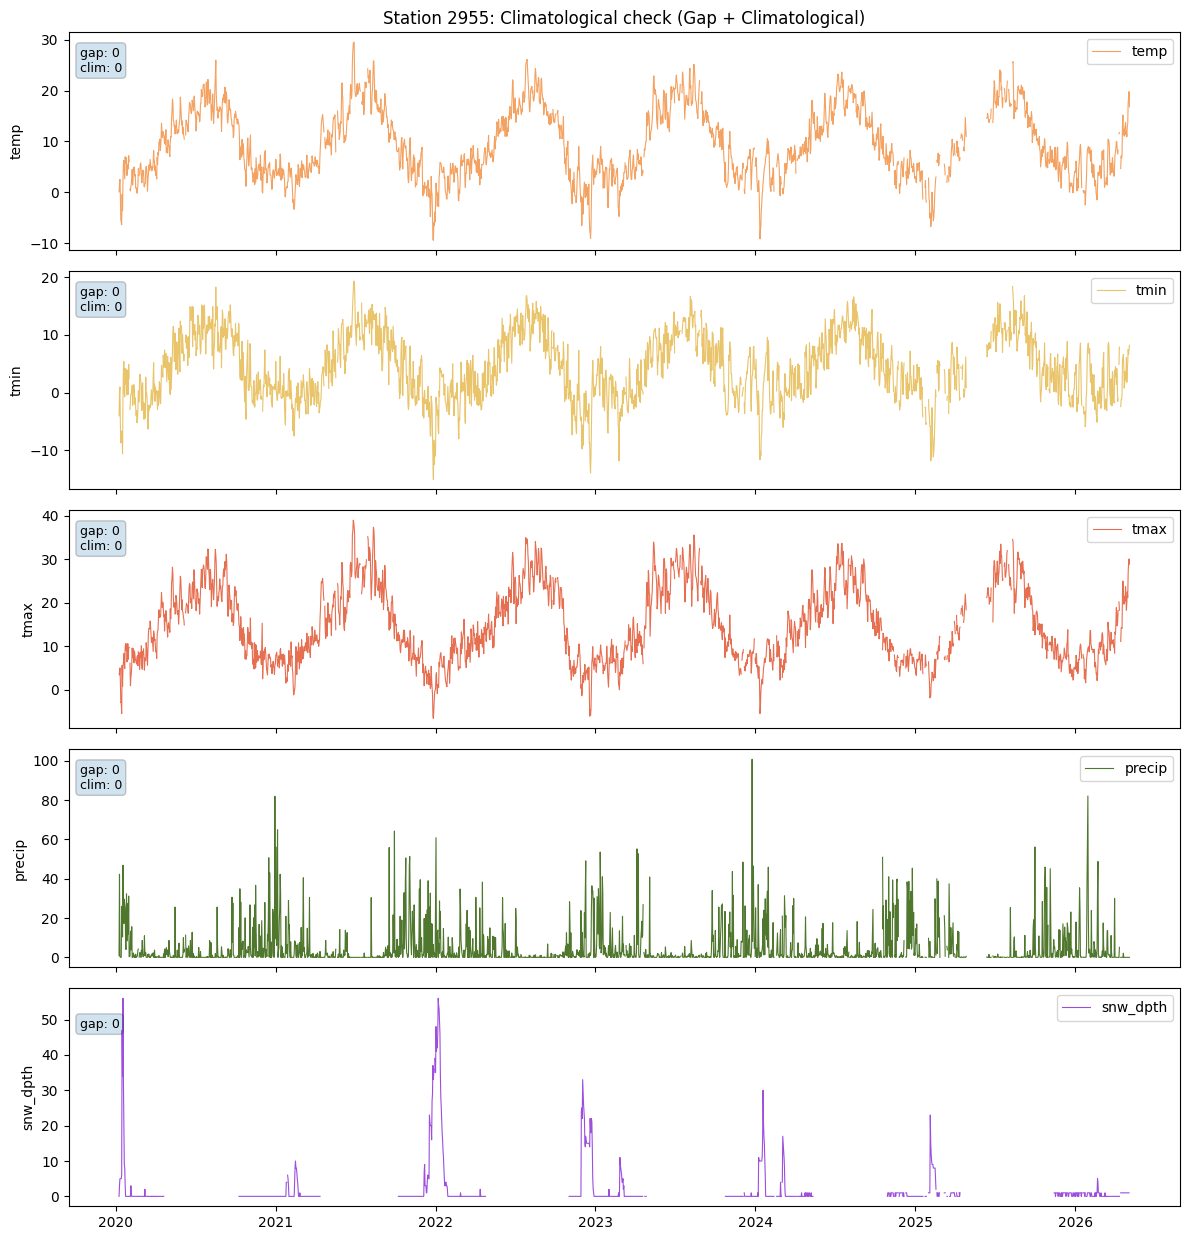

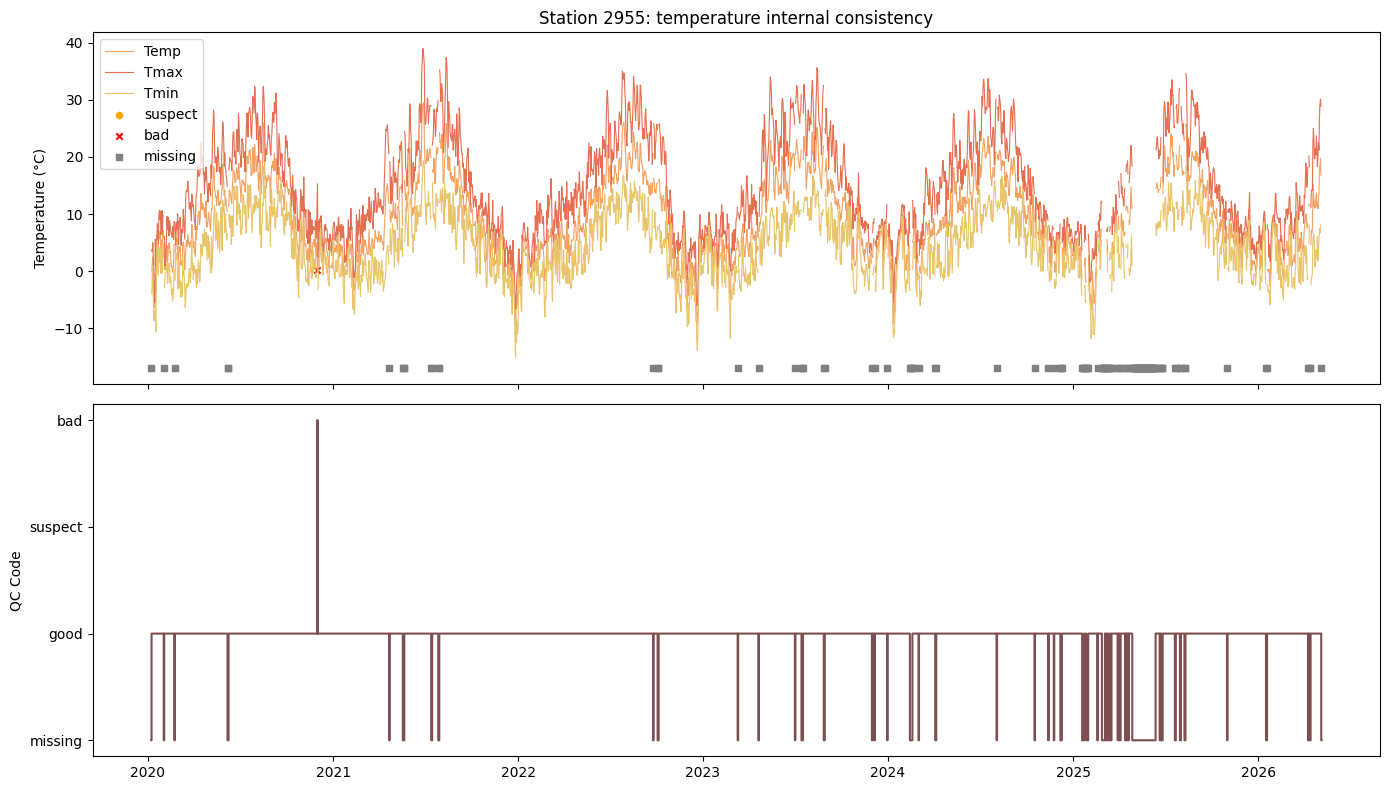

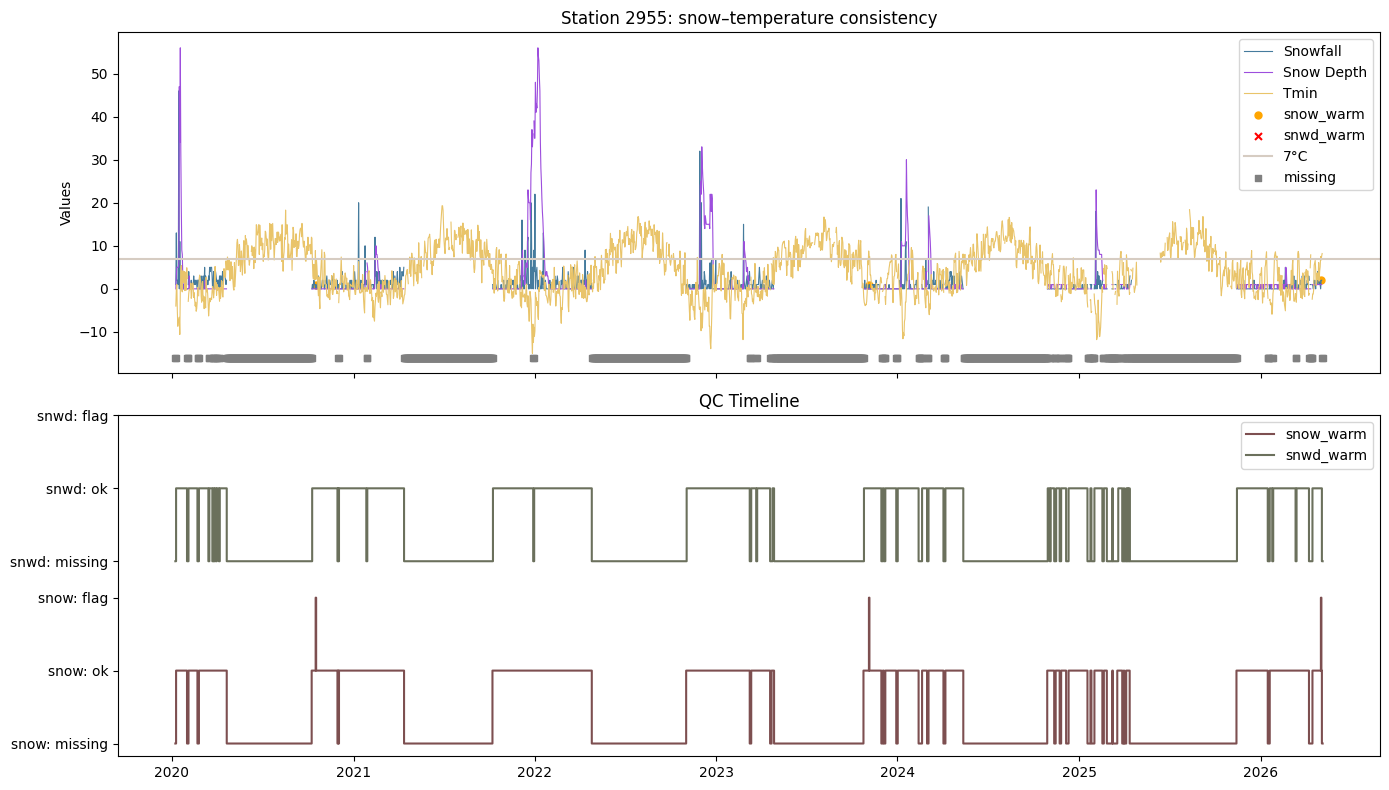

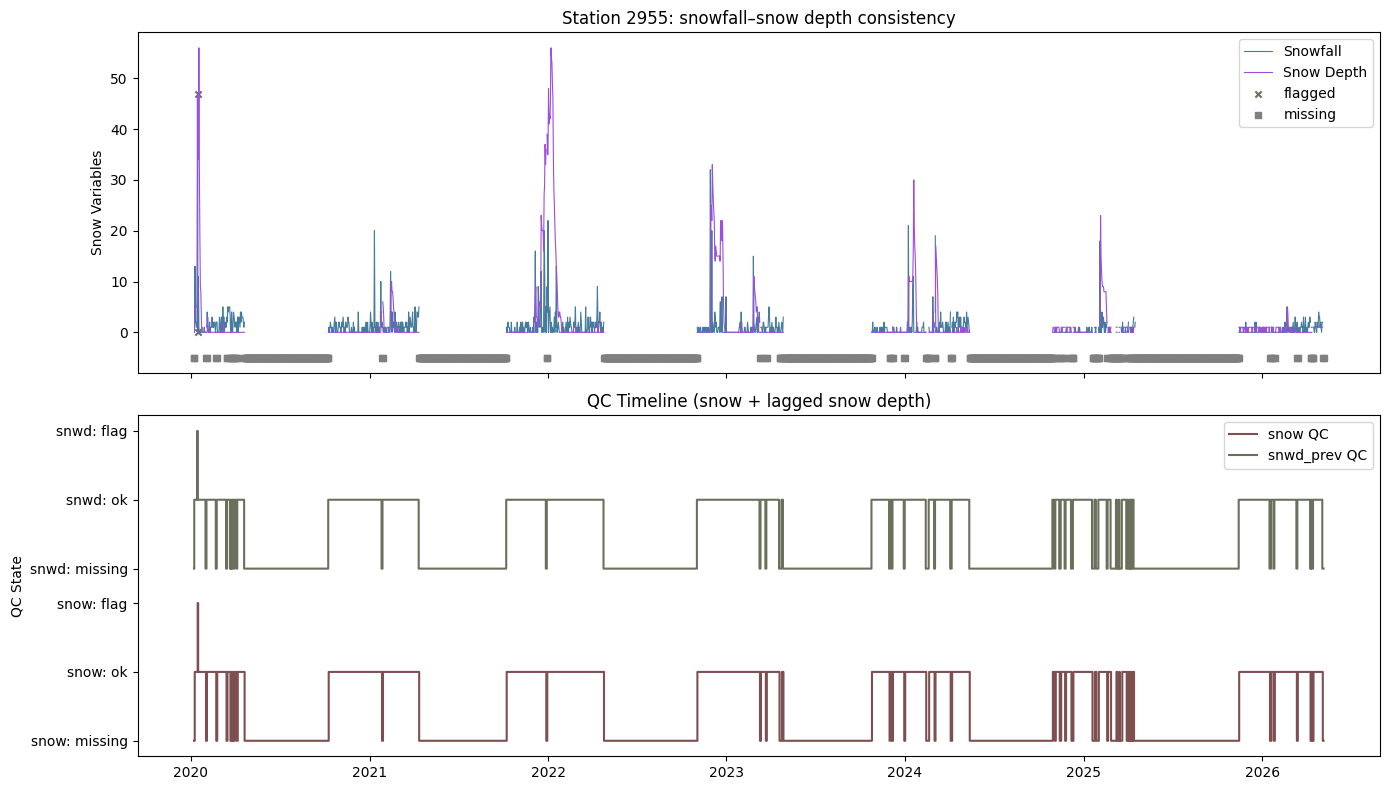

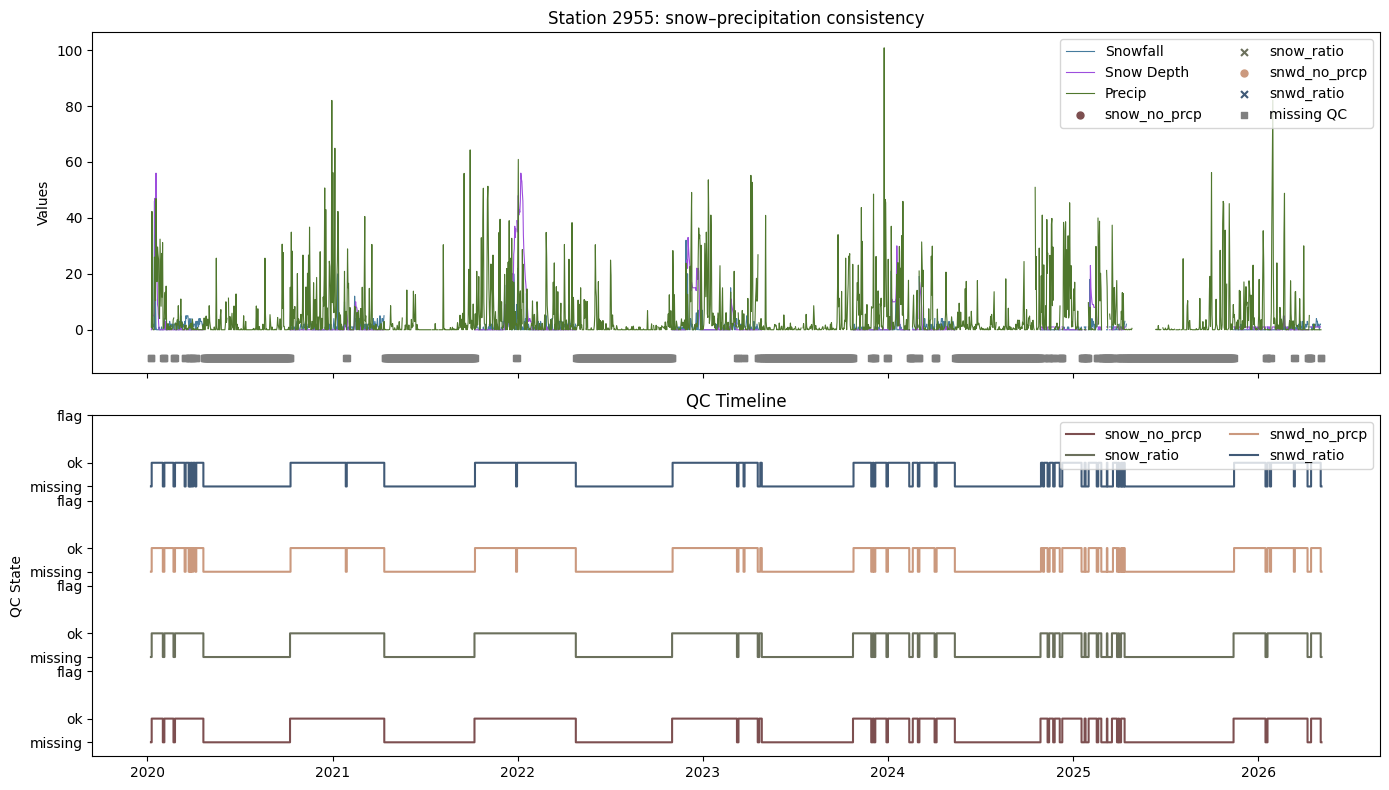

In [ ]:
value_cols = ["temp", "tmin", "tmax", "precip", "snw_fall", "snw_dpth"]
color_map = {
    "temp": "#f4a261",
    "tmin": "#e9c46a",
    "tmax": "#e76f51",
    "snw_fall": "#457b9d",
    "snw_dpth": "#9d4edd",
    "precip": "#4f772d",
}


for station_id, df_station in df_obs.groupby("station_id"):
    print("" + "=" * 80)
    print(f"Station {station_id}")
    print("=" * 80)

    daily_all = build_daily_all(df_station)
    result = run_qc_result_pipeline(daily_all, value_cols)


    plot_weather_data(
        daily_all,
        color_map=color_map,
        title=f"Station {station_id}: raw daily data"
    )

    plot_timeseries_with_naught_missing_multi(
        df=daily_all,
        color_map=color_map,
        naught_all=result["naught_all"],
        miss_result_dict=result["miss_result_dict"],
        value_cols=value_cols,
        title=f"Station {station_id}: raw daily series with naught + missing flags"
    )

    plot_multi_range_check(
        df=daily_all,
        wmo_rules=result["wmo_rules"],
        range_results=result["range_results"],
        color_map=color_map,
        outrange_scatter_color="#843939",
        title=f"Station {station_id}: WMO Range Check"

    )

    daily_cleaned = result['daily_cleaned']

    plot_weather_data(
        daily_cleaned,
        color_map=color_map,
        title=f"Station {station_id}: cleaned daily data"
    )

    gap_flags = pd.concat(
        {col: res["flag"] for col, res in result["gap_result_dict"].items()},
        axis=1
    ) if result["gap_result_dict"] else pd.DataFrame(index=daily_all.index)

    plot_clim_check_multi(
        df=daily_cleaned,
        color_map=color_map,
        gap_flags=gap_flags,
        clim_flags=result["clim_flag_df"],
        show_gap=True,
        show_clim=True,
        title=f"Station {station_id}: Climatological check (Gap + Climatological)"

    )

    plot_inttemp_tas_timeseries(
        result["inttemp_tas_result"],
        color_map=color_map,
        missing_color="gray",
        state_color="#7d4f50",
        title=f"Station {station_id}: temperature internal consistency"
    )

    plot_inttemp_snow_tmin_timeseries(
        daily_cleaned,
        result["inttemp_snow_tmin_result"],
        color_map=color_map,
        missing_color="gray",
        state_color=["#7d4f50", "#6b705c"],
        title=f"Station {station_id}: snow–temperature consistency"
    )

    plot_inttemp_snow_fall_dpth_timeseries(
        daily_cleaned,
        result["inttemp_snow_fall_dpth_result"],
        color_map=color_map,
        missing_color="gray",
        state_color=["#7d4f50", "#6b705c"],
        title=f"Station {station_id}: snowfall–snow depth consistency"
    )

    plot_inttemp_snow_precip_timeseries(
        daily_cleaned,
        result["inttemp_snow_precip_result"],
        color_map=color_map,
        missing_color="gray",
        state_color=["#7d4f50", "#6b705c", "#cb997e", "#415a77"],
        title=f"Station {station_id}: snow–precipitation consistency"
    )

In [46]:
from func_summary_tables import (
    create_cleaned_dataset_with_flags,
    create_flag_summary,
    create_station_evaluation_summary,
    summarize_variable_flag_rate,
)

from func_analyze_temporal_coverage import analyze_temporal_coverage

# Initialize lists to collect results across all stations
all_cleaned_with_flags = []
all_flag_summaries = []
all_station_summaries = []

# Re-run the analysis to collect summary tables
for station_id, df_station in df_obs.groupby("station_id"):
    daily_all = build_daily_all(df_station)
    result = run_qc_result_pipeline(daily_all, value_cols)

    # Generate cleaned dataset with all flags
    cleaned_with_flags = create_cleaned_dataset_with_flags(
        station_id,
        result["daily_cleaned"],
        result["naught_all"],
        result["range_results"],
        result["dup_result_dict"],
        result["ind_result_dict"],
        result["gap_result_dict"],
        result["clim_flag_df"],
        result["inttemp_tas_result"],
        result["inttemp_snow_tmin_result"],
        result["inttemp_snow_fall_dpth_result"],
        result["inttemp_snow_precip_result"],
        value_cols
    )

    all_cleaned_with_flags.append(cleaned_with_flags)

    # Generate flag summary (now with correct missing percentage from miss_result_dict)
    flag_summary = create_flag_summary(
        cleaned_with_flags, station_id, value_cols,
        miss_result_dict=result["miss_result_dict"])
    all_flag_summaries.append(flag_summary)

    flag_summary_var = summarize_variable_flag_rate(flag_summary)

    completeness_by_year = analyze_temporal_coverage(
        daily_cleaned, value_cols, miss_result_dict=result["miss_result_dict"])

    variable_quality = evaluate_station_quality(
        daily_cleaned,
        value_cols,
        miss_result_dict=result["miss_result_dict"],
        summary_flags=flag_summary_var)

    # Overall station rating
    station_rating, recommendation = get_station_rating(
        [q["rating"] for q in variable_quality.values()]
    )
    print(station_rating)
    print(recommendation)
    # Generate station evaluation summary
    years_list = list(range(daily_all.index.year.min(),
                      daily_all.index.year.max() + 1))

    station_summary = create_station_evaluation_summary(
        station_id,
        str(daily_all.index.min().date()),
        str(daily_all.index.max().date()),
        years_list,
        completeness_by_year,
        variable_quality,
        station_rating,
        recommendation,
        value_cols
    )
    all_station_summaries.append(station_summary)

# Combine all results into flat tables
cleaned_data_master = pd.concat(all_cleaned_with_flags, ignore_index=True)
flag_summary_master = pd.concat(all_flag_summaries, ignore_index=True)
station_summary_master = pd.concat(all_station_summaries, ignore_index=True)

STATION QUALITY EVALUATION SUMMARY (QC SCORING ENGINE)

VARIABLE-BY-VARIABLE QUALITY ASSESSMENT
--------------------------------------------------------------------------------

✅ TEMP         GOOD        
   Missing rate:   5.24%
   Flag rate:      0.04%
   Large gaps:   NO

✅ TMIN         GOOD        
   Missing rate:   5.24%
   Flag rate:      0.26%
   Large gaps:   NO

✅ TMAX         GOOD        
   Missing rate:   5.24%
   Flag rate:      0.00%
   Large gaps:   NO

✅ PRECIP       GOOD        
   Missing rate:   5.24%
   Flag rate:      0.00%
   Large gaps:   NO

✅ SNW_FALL     GOOD        
   Missing rate:   2.93%
   Flag rate:      0.35%
   Large gaps:   NO

✅ SNW_DPTH     GOOD        
   Missing rate:   4.16%
   Flag rate:      0.13%
   Large gaps:   NO

TEMPORAL COVERAGE ASSESSMENT
--------------------------------------------------------------------------------

Period: 2020-01-08 → 2026-05-06
Years: 2020–2026 (7 years)
Status: ✅ CONTINUOUS

SUMMARY:
  ✅ GOOD        : 6

✅ GOOD

## Export Summary Tables to CSV

Save the generated summary tables to CSV files for external analysis and reporting.

In [47]:
import os
from pathlib import Path

# Create output directory if it doesn't exist
output_dir = Path(
    '/workspaces/crmprtd/Quanlity_Control/single_station/evaluation_table')
output_dir.mkdir(parents=True, exist_ok=True)

# Save the three summary tables to CSV
cleaned_data_file = output_dir / 'cleaned_data_with_flags.csv'
flag_summary_file = output_dir / 'flag_summary.csv'
station_summary_file = output_dir / 'station_evaluation_summary.csv'

cleaned_data_master.to_csv(cleaned_data_file, index=False)
flag_summary_master.to_csv(flag_summary_file, index=False)
station_summary_master.to_csv(station_summary_file, index=False)

print(f"✅ CSV files saved successfully!\n")
print(f"1. Cleaned data with flags: {cleaned_data_file}")
print(f"   Shape: {cleaned_data_master.shape}\n")
print(f"2. Flag summary: {flag_summary_file}")
print(f"   Shape: {flag_summary_master.shape}\n")
print(f"3. Station evaluation summary: {station_summary_file}")
print(f"   Shape: {station_summary_master.shape}")

✅ CSV files saved successfully!

1. Cleaned data with flags: /workspaces/crmprtd/Quanlity_Control/single_station/evaluation_table/cleaned_data_with_flags.csv
   Shape: (23110, 69)

2. Flag summary: /workspaces/crmprtd/Quanlity_Control/single_station/evaluation_table/flag_summary.csv
   Shape: (680, 5)

3. Station evaluation summary: /workspaces/crmprtd/Quanlity_Control/single_station/evaluation_table/station_evaluation_summary.csv
   Shape: (70, 10)
